In [1]:
# 3. Package Installation
!pip install -q transformers fvcore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# 4. Imports
import gc
import math
import random
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from torchvision.transforms import InterpolationMode

from transformers import AutoImageProcessor, SwinForImageClassification
from fvcore.nn import FlopCountAnalysis


In [3]:
# 5. Seed Function
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [4]:
# 6. Device and Seed Execution
SEED = 42
set_all_seeds(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("CUDA Available:", torch.cuda.is_available())
print("Precision: float32")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
CUDA Available: True
Precision: float32
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [5]:
# 7. Common Configuration
COMMON_CONFIG = {
    "seed": SEED,
    "data_root": "./data",
    "num_classes": 100,
    "image_size": 32,
    "validation_fraction": 0.10,
    "num_workers": 2,
    "pin_memory": torch.cuda.is_available(),
}

PROBLEM1_CONFIG = {
    "batch_size": 64,
    "epochs": 10,
    "learning_rate": 0.001,
}

PROBLEM2_CONFIG = {
    "batch_size": 32,
    "epochs": 5,
    "pretrained_learning_rate": 2e-5,
    "scratch_learning_rate": 0.001,
}

QUALITATIVE_INDICES = [
    0, 1, 2, 3, 4, 5,
    6, 7, 8, 9, 10, 11
]


# 8. Dataset Description

In [6]:
# 9. Dataset Loading Functions
def load_raw_cifar100(root):
    training_dataset = datasets.CIFAR100(
        root=root,
        train=True,
        download=True
    )

    test_dataset = datasets.CIFAR100(
        root=root,
        train=False,
        download=True
    )

    return training_dataset, test_dataset


In [7]:
# 10. Cleaning Functions
def validate_cifar100(dataset):
    labels = np.asarray(dataset.targets)

    assert len(dataset) > 0
    assert labels.min() == 0
    assert labels.max() == 99
    assert len(np.unique(labels)) == 100

    return {
        "samples": len(dataset),
        "classes": len(np.unique(labels)),
        "minimum_label": int(labels.min()),
        "maximum_label": int(labels.max()),
    }


In [8]:
# 11. Vocabulary or Label Mapping
RAW_TRAIN_DATASET, RAW_TEST_DATASET = load_raw_cifar100(
    COMMON_CONFIG["data_root"]
)

CLASS_NAMES = RAW_TRAIN_DATASET.classes
LABEL_TO_NAME = dict(enumerate(CLASS_NAMES))
NAME_TO_LABEL = {
    name: index
    for index, name in LABEL_TO_NAME.items()
}

pd.DataFrame(
    list(LABEL_TO_NAME.items())[:20],
    columns=["Label", "Class Name"]
)


100%|██████████| 169M/169M [44:43<00:00, 63.0kB/s]


,Label,Class Name
0,0,apple
1,1,aquarium_fish
2,2,baby
3,3,bear
4,4,beaver
5,5,bed
6,6,bee
7,7,beetle
8,8,bicycle
9,9,bottle


In [9]:
# 12. Dataset Class
class TransformSubsetDataset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        transform=None
    ):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, label = self.base_dataset[
            self.indices[index]
        ]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [10]:
# 13. Sample Construction Functions
def create_dataset_subsets(
    training_transform,
    evaluation_transform,
    training_indices,
    validation_indices
):
    training_dataset = TransformSubsetDataset(
        RAW_TRAIN_DATASET,
        training_indices,
        training_transform
    )

    clean_training_dataset = TransformSubsetDataset(
        RAW_TRAIN_DATASET,
        training_indices,
        evaluation_transform
    )

    validation_dataset = TransformSubsetDataset(
        RAW_TRAIN_DATASET,
        validation_indices,
        evaluation_transform
    )

    test_dataset = TransformSubsetDataset(
        RAW_TEST_DATASET,
        range(len(RAW_TEST_DATASET)),
        evaluation_transform
    )

    return (
        training_dataset,
        clean_training_dataset,
        validation_dataset,
        test_dataset
    )


In [11]:
# 14. Load and Preprocess Data
training_validation_report = validate_cifar100(
    RAW_TRAIN_DATASET
)

test_validation_report = validate_cifar100(
    RAW_TEST_DATASET
)

print("Training Dataset:", training_validation_report)
print("Test Dataset:", test_validation_report)
print("Raw Image Size:", RAW_TRAIN_DATASET[0][0].size)


Training Dataset: {'samples': 50000, 'classes': 100, 'minimum_label': 0, 'maximum_label': 99}
Test Dataset: {'samples': 10000, 'classes': 100, 'minimum_label': 0, 'maximum_label': 99}
Raw Image Size: (32, 32)


In [12]:
# 15. Training-Validation Split
split_generator = torch.Generator().manual_seed(SEED)

permutation = torch.randperm(
    len(RAW_TRAIN_DATASET),
    generator=split_generator
).tolist()

validation_size = int(
    len(RAW_TRAIN_DATASET)
    * COMMON_CONFIG["validation_fraction"]
)

VALIDATION_INDICES = permutation[:validation_size]
TRAIN_INDICES = permutation[validation_size:]

print("Training Samples:", len(TRAIN_INDICES))
print("Validation Samples:", len(VALIDATION_INDICES))


Training Samples: 45000
Validation Samples: 5000


In [13]:
# 16. Test-Set Setup
TEST_INDICES = list(range(len(RAW_TEST_DATASET)))

print("Test Samples:", len(TEST_INDICES))


Test Samples: 10000


In [14]:
# 17. DataLoader Function
def seed_worker(worker_id):
    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_dataloader(
    dataset,
    batch_size,
    shuffle,
    seed=SEED
):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=COMMON_CONFIG["num_workers"],
        pin_memory=COMMON_CONFIG["pin_memory"],
        persistent_workers=False,
        worker_init_fn=seed_worker,
        generator=generator
    )


In [15]:
# 18. Create DataLoaders
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

SWIN_TINY_CHECKPOINT = (
    "microsoft/swin-tiny-patch4-window7-224"
)

SWIN_SMALL_CHECKPOINT = (
    "microsoft/swin-small-patch4-window7-224"
)

SWIN_PROCESSOR = AutoImageProcessor.from_pretrained(
    SWIN_TINY_CHECKPOINT
)

SWIN_MEAN = tuple(SWIN_PROCESSOR.image_mean)
SWIN_STD = tuple(SWIN_PROCESSOR.image_std)

processor_size = SWIN_PROCESSOR.size

if "height" in processor_size:
    SWIN_IMAGE_SIZE = (
        processor_size["height"],
        processor_size["width"]
    )
elif "shortest_edge" in processor_size:
    SWIN_IMAGE_SIZE = (
        processor_size["shortest_edge"],
        processor_size["shortest_edge"]
    )
else:
    SWIN_IMAGE_SIZE = (224, 224)

P1_TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        CIFAR100_MEAN,
        CIFAR100_STD
    ),
])

P1_EVAL_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        CIFAR100_MEAN,
        CIFAR100_STD
    ),
])

P2_TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize(
        SWIN_IMAGE_SIZE,
        interpolation=InterpolationMode.BICUBIC
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        SWIN_MEAN,
        SWIN_STD
    ),
])

P2_EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize(
        SWIN_IMAGE_SIZE,
        interpolation=InterpolationMode.BICUBIC
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        SWIN_MEAN,
        SWIN_STD
    ),
])

(
    P1_TRAIN_DATASET,
    P1_CLEAN_TRAIN_DATASET,
    P1_VALIDATION_DATASET,
    P1_TEST_DATASET
) = create_dataset_subsets(
    P1_TRAIN_TRANSFORM,
    P1_EVAL_TRANSFORM,
    TRAIN_INDICES,
    VALIDATION_INDICES
)

(
    P2_TRAIN_DATASET,
    P2_CLEAN_TRAIN_DATASET,
    P2_VALIDATION_DATASET,
    P2_TEST_DATASET
) = create_dataset_subsets(
    P2_TRAIN_TRANSFORM,
    P2_EVAL_TRANSFORM,
    TRAIN_INDICES,
    VALIDATION_INDICES
)

P1_TRAIN_LOADER = create_dataloader(
    P1_TRAIN_DATASET,
    PROBLEM1_CONFIG["batch_size"],
    True
)

P1_CLEAN_TRAIN_LOADER = create_dataloader(
    P1_CLEAN_TRAIN_DATASET,
    PROBLEM1_CONFIG["batch_size"],
    False
)

P1_VALIDATION_LOADER = create_dataloader(
    P1_VALIDATION_DATASET,
    PROBLEM1_CONFIG["batch_size"],
    False
)

P1_TEST_LOADER = create_dataloader(
    P1_TEST_DATASET,
    PROBLEM1_CONFIG["batch_size"],
    False
)

P2_TRAIN_LOADER = create_dataloader(
    P2_TRAIN_DATASET,
    PROBLEM2_CONFIG["batch_size"],
    True
)

P2_CLEAN_TRAIN_LOADER = create_dataloader(
    P2_CLEAN_TRAIN_DATASET,
    PROBLEM2_CONFIG["batch_size"],
    False
)

P2_VALIDATION_LOADER = create_dataloader(
    P2_VALIDATION_DATASET,
    PROBLEM2_CONFIG["batch_size"],
    False
)

P2_TEST_LOADER = create_dataloader(
    P2_TEST_DATASET,
    PROBLEM2_CONFIG["batch_size"],
    False
)


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

In [16]:
# 19. Verify Batch Shapes
p1_images, p1_labels = next(iter(P1_TRAIN_LOADER))
p2_images, p2_labels = next(iter(P2_TRAIN_LOADER))

print("Problem 1 Images:", p1_images.shape)
print("Problem 1 Labels:", p1_labels.shape)
print("Problem 2 Images:", p2_images.shape)
print("Problem 2 Labels:", p2_labels.shape)
print("Swin Image Size:", SWIN_IMAGE_SIZE)
print("Swin Mean:", SWIN_MEAN)
print("Swin Standard Deviation:", SWIN_STD)


Problem 1 Images: torch.Size([64, 3, 32, 32])
Problem 1 Labels: torch.Size([64])
Problem 2 Images: torch.Size([32, 3, 224, 224])
Problem 2 Labels: torch.Size([32])
Swin Image Size: (224, 224)
Swin Mean: (0.485, 0.456, 0.406)
Swin Standard Deviation: (0.229, 0.224, 0.225)


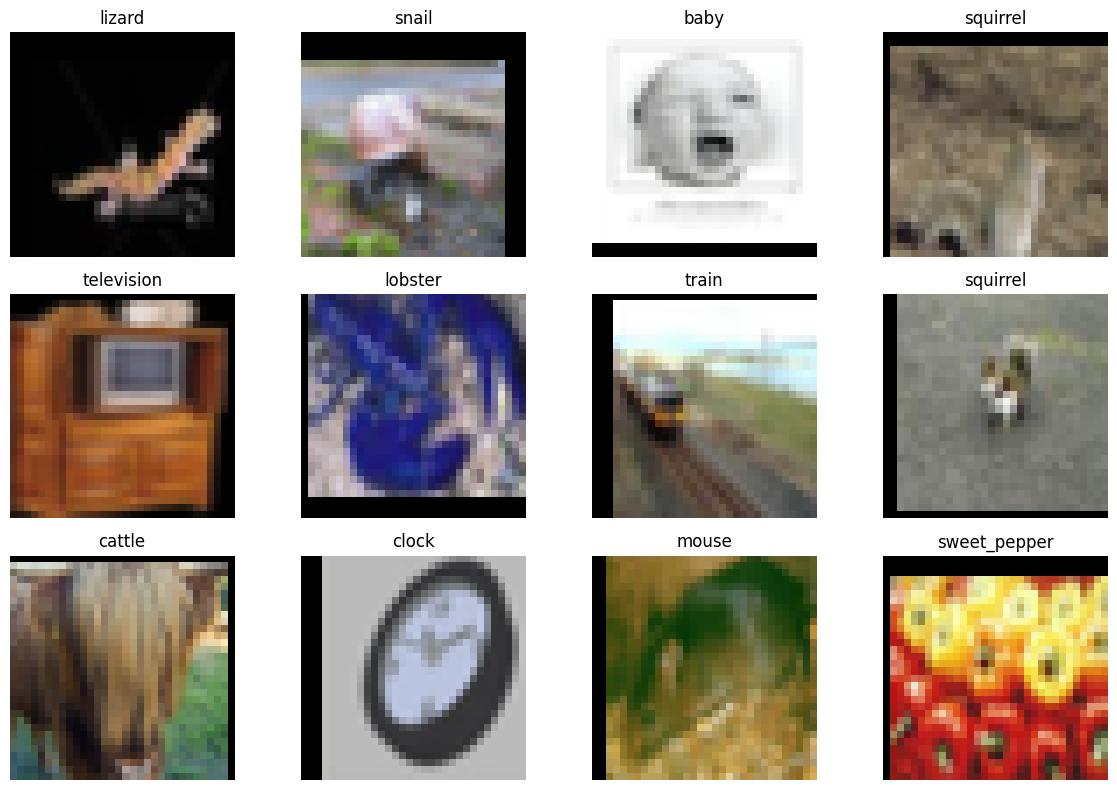

In [17]:
# 20. Display Sample Data
def denormalize(image, mean, standard_deviation):
    mean_tensor = torch.tensor(
        mean
    ).view(3, 1, 1)

    standard_deviation_tensor = torch.tensor(
        standard_deviation
    ).view(3, 1, 1)

    return (
        image * standard_deviation_tensor
        + mean_tensor
    )

sample_images, sample_labels = next(
    iter(P1_TRAIN_LOADER)
)

plt.figure(figsize=(12, 8))

for index in range(12):
    plt.subplot(3, 4, index + 1)

    image = denormalize(
        sample_images[index].cpu(),
        CIFAR100_MEAN,
        CIFAR100_STD
    )

    image = image.permute(
        1,
        2,
        0
    ).clamp(0, 1)

    plt.imshow(image)
    plt.title(
        CLASS_NAMES[
            sample_labels[index].item()
        ]
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [18]:
# 21. Parameter-Count Helpers
class LogitWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, images):
        output = self.model(images)

        if hasattr(output, "logits"):
            return output.logits

        return output


def count_parameters(model):
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    frozen_parameters = (
        total_parameters
        - trainable_parameters
    )

    model_size_mb = (
        total_parameters
        * 4
        / (1024 ** 2)
    )

    return {
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "frozen_parameters": frozen_parameters,
        "model_size_mb": model_size_mb,
    }


def copy_state_to_cpu(model):
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor
        in model.state_dict().items()
    }


def calculate_supported_flops(
    model,
    input_shape
):
    original_device = next(
        model.parameters()
    ).device

    model = model.to(DEVICE)
    model.eval()

    wrapped_model = LogitWrapper(model)

    sample_input = torch.randn(
        *input_shape,
        device=DEVICE
    )

    analysis = FlopCountAnalysis(
        wrapped_model,
        sample_input
    )

    analysis.unsupported_ops_warnings(False)
    analysis.uncalled_modules_warnings(False)

    try:
        estimated_flops = analysis.total()
        unsupported_operations = dict(
            analysis.unsupported_ops()
        )
    except Exception as error:
        estimated_flops = np.nan
        unsupported_operations = {
            "profiling_error": str(error)
        }

    model = model.to(original_device)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "estimated_flops": estimated_flops,
        "flop_method": "fvcore supported operations",
        "unsupported_operations": str(
            unsupported_operations
        ),
    }


In [19]:
# 22. Metric Functions
def top1_correct(logits, targets):
    return (
        logits.argmax(dim=1)
        == targets
    ).sum().item()


def top5_correct(logits, targets):
    top5_predictions = logits.topk(
        5,
        dim=1
    ).indices

    return top5_predictions.eq(
        targets.view(-1, 1)
    ).any(dim=1).sum().item()


def classify_learning_status(result):
    history = result["history"]

    all_losses = (
        history["training_loss"]
        + history["validation_loss"]
    )

    if not all(
        np.isfinite(value)
        for value in all_losses
    ):
        return "Invalid run: nonfinite loss"

    best_index = (
        result["best_validation_loss_epoch"]
        - 1
    )

    final_index = (
        len(history["validation_loss"])
        - 1
    )

    train_loss_at_best = history[
        "training_loss"
    ][best_index]

    final_train_loss = history[
        "training_loss"
    ][final_index]

    validation_loss_at_best = history[
        "validation_loss"
    ][best_index]

    final_validation_loss = history[
        "validation_loss"
    ][final_index]

    if result["best_validation_accuracy"] <= 0.02:
        return "Failed learning / severe underfitting"

    if (
        final_train_loss < train_loss_at_best
        and final_validation_loss
        > validation_loss_at_best
    ):
        return (
            "Overfitting after best "
            "validation-loss epoch"
        )

    if (
        result["best_validation_loss_epoch"]
        == len(history["validation_loss"])
    ):
        return "Still converging at final epoch"

    minimum_training_loss = min(
        history["training_loss"]
    )

    if (
        final_train_loss
        > minimum_training_loss * 1.05
        and final_validation_loss
        > validation_loss_at_best * 1.02
    ):
        return "Optimization instability"

    return "Stable or mixed convergence"


In [20]:
# 23. Batch Preparation
def prepare_batch(batch, device):
    images, labels = batch

    images = images.to(
        device,
        non_blocking=True
    )

    labels = labels.to(
        device,
        non_blocking=True
    )

    return images, labels


def synchronize_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


In [21]:
# 24. Loss-Shape Preparation
def extract_logits(model_output):
    if hasattr(model_output, "logits"):
        return model_output.logits

    return model_output


In [22]:
# 25. Train-One-Epoch Function
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    synchronize_device()
    start_time = time.perf_counter()

    for batch in data_loader:
        images, labels = prepare_batch(
            batch,
            device
        )

        optimizer.zero_grad(set_to_none=True)

        logits = extract_logits(
            model(images)
        )

        loss = criterion(
            logits,
            labels
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Nonfinite training loss "
                f"detected: {loss.item()}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_size = labels.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        total_correct += top1_correct(
            logits,
            labels
        )

        total_samples += batch_size

    synchronize_device()
    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "time": elapsed_time,
    }


In [23]:
# 26. Validation-One-Epoch Function
def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    synchronize_device()
    start_time = time.perf_counter()

    with torch.no_grad():
        for batch in data_loader:
            images, labels = prepare_batch(
                batch,
                device
            )

            logits = extract_logits(
                model(images)
            )

            loss = criterion(
                logits,
                labels
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Nonfinite validation loss "
                    f"detected: {loss.item()}"
                )

            batch_size = labels.size(0)

            total_loss += (
                loss.item()
                * batch_size
            )

            total_correct += top1_correct(
                logits,
                labels
            )

            total_samples += batch_size

    synchronize_device()
    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "time": elapsed_time,
    }


In [24]:
# 27. Full Training Function
def train_model(
    model,
    training_loader,
    validation_loader,
    criterion,
    optimizer,
    epochs,
    model_name
):
    history = {
        "training_loss": [],
        "validation_loss": [],
        "training_accuracy": [],
        "validation_accuracy": [],
        "training_time": [],
        "validation_time": [],
        "complete_epoch_time": [],
    }

    best_validation_loss = float("inf")
    best_validation_accuracy = -float("inf")

    best_loss_state = None
    best_accuracy_state = None

    best_loss_epoch = None
    best_accuracy_epoch = None

    if training_loader.generator is not None:
        training_loader.generator.manual_seed(
            SEED
        )

    for epoch in range(1, epochs + 1):
        complete_epoch_start = (
            time.perf_counter()
        )

        training_metrics = train_one_epoch(
            model,
            training_loader,
            criterion,
            optimizer,
            DEVICE
        )

        validation_metrics = validate_one_epoch(
            model,
            validation_loader,
            criterion,
            DEVICE
        )

        complete_epoch_time = (
            time.perf_counter()
            - complete_epoch_start
        )

        history["training_loss"].append(
            training_metrics["loss"]
        )

        history["validation_loss"].append(
            validation_metrics["loss"]
        )

        history["training_accuracy"].append(
            training_metrics["accuracy"]
        )

        history["validation_accuracy"].append(
            validation_metrics["accuracy"]
        )

        history["training_time"].append(
            training_metrics["time"]
        )

        history["validation_time"].append(
            validation_metrics["time"]
        )

        history["complete_epoch_time"].append(
            complete_epoch_time
        )

        if (
            validation_metrics["loss"]
            < best_validation_loss
        ):
            best_validation_loss = (
                validation_metrics["loss"]
            )

            best_loss_epoch = epoch

            best_loss_state = (
                copy_state_to_cpu(model)
            )

        if (
            validation_metrics["accuracy"]
            > best_validation_accuracy
        ):
            best_validation_accuracy = (
                validation_metrics["accuracy"]
            )

            best_accuracy_epoch = epoch

            best_accuracy_state = (
                copy_state_to_cpu(model)
            )

        print(
            f"{model_name} | "
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train Loss "
            f"{training_metrics['loss']:.4f} | "
            f"Val Loss "
            f"{validation_metrics['loss']:.4f} | "
            f"Train Acc "
            f"{training_metrics['accuracy']:.4f} | "
            f"Val Acc "
            f"{validation_metrics['accuracy']:.4f} | "
            f"Train Time "
            f"{training_metrics['time']:.2f}s | "
            f"Complete Time "
            f"{complete_epoch_time:.2f}s"
        )

    return {
        "history": history,
        "best_validation_loss": (
            best_validation_loss
        ),
        "best_validation_accuracy": (
            best_validation_accuracy
        ),
        "best_loss_epoch": best_loss_epoch,
        "best_accuracy_epoch": (
            best_accuracy_epoch
        ),
        "best_loss_state": best_loss_state,
        "best_accuracy_state": (
            best_accuracy_state
        ),
    }


In [25]:
# 28. Checkpoint Restoration
def restore_best_validation_loss_checkpoint(
    model,
    training_result
):
    model.load_state_dict(
        training_result["best_loss_state"]
    )

    return model


In [26]:
# 29. Final Evaluation Function
def evaluate_model(
    model,
    data_loader,
    criterion
):
    model.eval()

    total_loss = 0.0
    total_top1 = 0
    total_top5 = 0
    total_samples = 0

    predictions = []
    labels_list = []

    synchronize_device()
    start_time = time.perf_counter()

    with torch.no_grad():
        for batch in data_loader:
            images, labels = prepare_batch(
                batch,
                DEVICE
            )

            logits = extract_logits(
                model(images)
            )

            loss = criterion(
                logits,
                labels
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Nonfinite evaluation loss "
                    f"detected: {loss.item()}"
                )

            batch_size = labels.size(0)

            total_loss += (
                loss.item()
                * batch_size
            )

            total_top1 += top1_correct(
                logits,
                labels
            )

            total_top5 += top5_correct(
                logits,
                labels
            )

            total_samples += batch_size

            predictions.extend(
                logits.argmax(
                    dim=1
                ).cpu().tolist()
            )

            labels_list.extend(
                labels.cpu().tolist()
            )

    synchronize_device()
    evaluation_time = (
        time.perf_counter()
        - start_time
    )

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_top1 / total_samples,
        "top5_accuracy": (
            total_top5 / total_samples
        ),
        "evaluation_time": evaluation_time,
        "predictions": predictions,
        "labels": labels_list,
    }


In [27]:
# 30. Loss Plot Function
def plot_loss_history(
    history,
    model_name
):
    epochs = range(
        1,
        len(history["training_loss"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["training_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


In [28]:
# 31. Metric Plot Function
def plot_accuracy_history(
    history,
    model_name
):
    epochs = range(
        1,
        len(history["training_accuracy"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["training_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["validation_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [29]:
# 32. Combined History Function
def display_history(
    result
):
    history = result["history"]

    plot_loss_history(
        history,
        result["model_name"]
    )

    plot_accuracy_history(
        history,
        result["model_name"]
    )

    return pd.DataFrame({
        "Epoch": range(
            1,
            len(history["training_loss"]) + 1
        ),
        "Training Loss": (
            history["training_loss"]
        ),
        "Validation Loss": (
            history["validation_loss"]
        ),
        "Training Accuracy": (
            history["training_accuracy"]
        ),
        "Validation Accuracy": (
            history["validation_accuracy"]
        ),
        "Training Time": (
            history["training_time"]
        ),
        "Validation Time": (
            history["validation_time"]
        ),
        "Complete Epoch Time": (
            history["complete_epoch_time"]
        ),
    })


In [30]:
# 33. Comparison Plot Functions
def plot_result_metric(
    results,
    metric,
    title,
    y_label
):
    names = [
        result["model_name"]
        for result in results
    ]

    values = [
        result[metric]
        for result in results
    ]

    plt.figure(figsize=(12, 6))
    plt.bar(names, values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [31]:
# 34. Prediction or Generation Function
def predict_batch(
    model,
    images
):
    model.eval()

    with torch.no_grad():
        logits = extract_logits(
            model(images.to(DEVICE))
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, predictions = (
            probabilities.max(dim=1)
        )

    return (
        predictions.cpu(),
        confidence.cpu(),
        probabilities.cpu()
    )


In [32]:
# 35. Qualitative-Result Function
def display_predictions_on_indices(
    model,
    raw_dataset,
    indices,
    transform
):
    transformed_images = []

    for index in indices:
        raw_image, _ = raw_dataset[index]
        transformed_images.append(
            transform(raw_image)
        )

    image_batch = torch.stack(
        transformed_images
    )

    predictions, confidence, _ = (
        predict_batch(
            model,
            image_batch
        )
    )

    plt.figure(figsize=(12, 8))

    for plot_index, dataset_index in enumerate(
        indices
    ):
        raw_image, true_label = (
            raw_dataset[dataset_index]
        )

        plt.subplot(3, 4, plot_index + 1)
        plt.imshow(raw_image)

        plt.title(
            f"T: {CLASS_NAMES[true_label]}\n"
            f"P: "
            f"{CLASS_NAMES[predictions[plot_index].item()]}\n"
            f"C: "
            f"{confidence[plot_index].item():.2f}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


Class: cattle


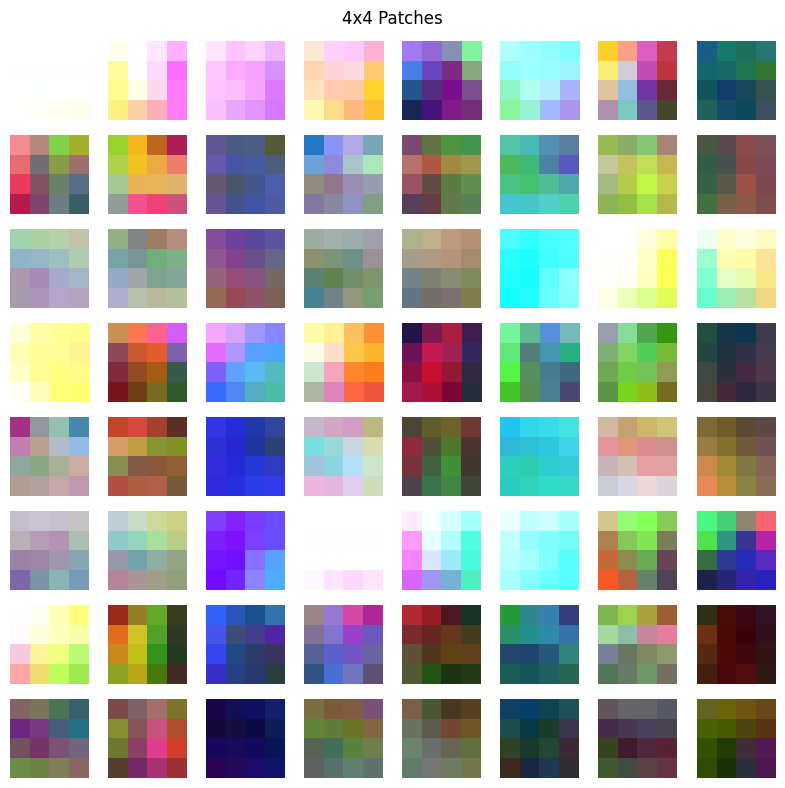

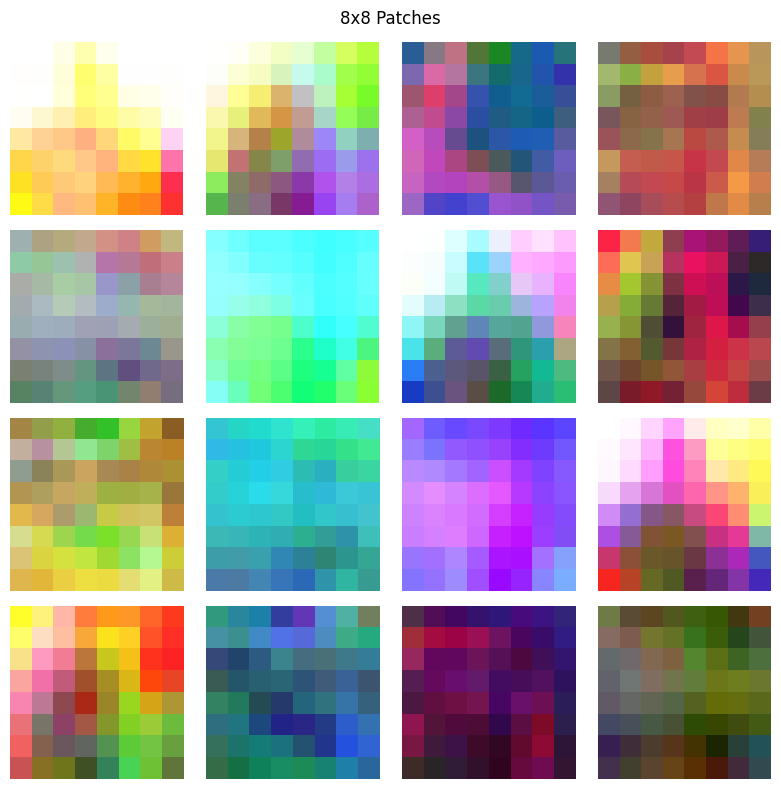

In [33]:
# 36. Special Visualization Function
def visualize_patches(
    image,
    patch_size
):
    image = image.unsqueeze(0)

    patches = image.unfold(
        2,
        patch_size,
        patch_size
    ).unfold(
        3,
        patch_size,
        patch_size
    )

    patches = patches.contiguous().view(
        -1,
        3,
        patch_size,
        patch_size
    )

    grid_size = int(
        math.sqrt(len(patches))
    )

    plt.figure(figsize=(8, 8))

    for index, patch in enumerate(patches):
        plt.subplot(
            grid_size,
            grid_size,
            index + 1
        )

        patch = patch.permute(
            1,
            2,
            0
        ).clamp(0, 1)

        plt.imshow(patch)
        plt.axis("off")

    plt.suptitle(
        f"{patch_size}x{patch_size} Patches"
    )
    plt.tight_layout()
    plt.show()


raw_patch_image, raw_patch_label = (
    RAW_TRAIN_DATASET[0]
)

patch_image_tensor = transforms.ToTensor()(
    raw_patch_image
)

print(
    "Class:",
    CLASS_NAMES[raw_patch_label]
)

visualize_patches(
    patch_image_tensor,
    patch_size=4
)

visualize_patches(
    patch_image_tensor,
    patch_size=8
)


In [34]:
# 37. Result-Summary Function
def create_result_record(
    model_name,
    model_family,
    training_mode,
    training_result,
    clean_training_result,
    validation_result,
    test_result,
    parameter_result,
    flop_result,
    configuration
):
    history = training_result["history"]

    best_loss_index = (
        training_result["best_loss_epoch"]
        - 1
    )

    best_accuracy_index = (
        training_result[
            "best_accuracy_epoch"
        ]
        - 1
    )

    result = {
        "model_name": model_name,
        "model_family": model_family,
        "training_mode": training_mode,
        "patch_size": configuration.get(
            "patch_size",
            np.nan
        ),
        "embedding_dimension": (
            configuration.get(
                "embedding_dimension",
                np.nan
            )
        ),
        "transformer_blocks": (
            configuration.get(
                "transformer_blocks",
                np.nan
            )
        ),
        "attention_heads": (
            configuration.get(
                "attention_heads",
                np.nan
            )
        ),
        "mlp_dimension": (
            configuration.get(
                "mlp_dimension",
                np.nan
            )
        ),
        "total_parameters": (
            parameter_result[
                "total_parameters"
            ]
        ),
        "trainable_parameters": (
            parameter_result[
                "trainable_parameters"
            ]
        ),
        "frozen_parameters": (
            parameter_result[
                "frozen_parameters"
            ]
        ),
        "model_size_mb": (
            parameter_result[
                "model_size_mb"
            ]
        ),
        "estimated_flops": (
            flop_result["estimated_flops"]
        ),
        "flop_method": (
            flop_result["flop_method"]
        ),
        "unsupported_operations": (
            flop_result[
                "unsupported_operations"
            ]
        ),
        "best_validation_loss_epoch": (
            training_result[
                "best_loss_epoch"
            ]
        ),
        "best_validation_loss": (
            training_result[
                "best_validation_loss"
            ]
        ),
        "validation_accuracy_at_best_loss": (
            history["validation_accuracy"][
                best_loss_index
            ]
        ),
        "best_validation_accuracy_epoch": (
            training_result[
                "best_accuracy_epoch"
            ]
        ),
        "best_validation_accuracy": (
            training_result[
                "best_validation_accuracy"
            ]
        ),
        "validation_loss_at_best_accuracy": (
            history["validation_loss"][
                best_accuracy_index
            ]
        ),
        "selected_validation_loss": (
            validation_result["loss"]
        ),
        "selected_validation_accuracy": (
            validation_result["accuracy"]
        ),
        "clean_training_loss": (
            clean_training_result["loss"]
        ),
        "clean_training_accuracy": (
            clean_training_result["accuracy"]
        ),
        "clean_generalization_gap": (
            clean_training_result["accuracy"]
            - validation_result["accuracy"]
        ),
        "test_loss": test_result["loss"],
        "test_accuracy": (
            test_result["accuracy"]
        ),
        "top5_accuracy": (
            test_result["top5_accuracy"]
        ),
        "mean_training_time_per_epoch": (
            float(
                np.mean(
                    history["training_time"]
                )
            )
        ),
        "mean_validation_time_per_epoch": (
            float(
                np.mean(
                    history["validation_time"]
                )
            )
        ),
        "mean_complete_epoch_time": (
            float(
                np.mean(
                    history[
                        "complete_epoch_time"
                    ]
                )
            )
        ),
        "total_training_time": (
            float(
                np.sum(
                    history["training_time"]
                )
            )
        ),
        "total_experiment_time": (
            float(
                np.sum(
                    history[
                        "complete_epoch_time"
                    ]
                )
            )
        ),
        "history": history,
    }

    result["learning_status"] = (
        classify_learning_status(result)
    )

    return result


def run_classification_experiment(
    model,
    model_name,
    model_family,
    training_mode,
    training_loader,
    clean_training_loader,
    validation_loader,
    test_loader,
    epochs,
    learning_rate,
    input_shape,
    configuration,
    flop_result=None
):
    set_all_seeds(SEED)

    if training_loader.generator is not None:
        training_loader.generator.manual_seed(
            SEED
        )

    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = optim.Adam(
        trainable_parameters,
        lr=learning_rate
    )

    training_result = train_model(
        model,
        training_loader,
        validation_loader,
        criterion,
        optimizer,
        epochs,
        model_name
    )

    model = (
        restore_best_validation_loss_checkpoint(
            model,
            training_result
        )
    )

    clean_training_result = evaluate_model(
        model,
        clean_training_loader,
        criterion
    )

    validation_result = evaluate_model(
        model,
        validation_loader,
        criterion
    )

    test_result = evaluate_model(
        model,
        test_loader,
        criterion
    )

    parameter_result = count_parameters(
        model
    )

    if flop_result is None:
        flop_result = (
            calculate_supported_flops(
                model,
                input_shape
            )
        )

    result = create_result_record(
        model_name,
        model_family,
        training_mode,
        training_result,
        clean_training_result,
        validation_result,
        test_result,
        parameter_result,
        flop_result,
        configuration
    )

    model = model.cpu()

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return model, result


# 38. Problem 1A: Vision Transformers from Scratch

In [35]:
# 39. Problem 1 Configuration
VIT_CONFIGURATIONS = [
    {
        "name": "ViT-P4-D256-L4-H4",
        "patch_size": 4,
        "embedding_dimension": 256,
        "transformer_blocks": 4,
        "attention_heads": 4,
        "mlp_dimension": 1024,
        "dropout": 0.1,
    },
    {
        "name": "ViT-P8-D256-L4-H4",
        "patch_size": 8,
        "embedding_dimension": 256,
        "transformer_blocks": 4,
        "attention_heads": 4,
        "mlp_dimension": 1024,
        "dropout": 0.1,
    },
    {
        "name": "ViT-P4-D256-L8-H4",
        "patch_size": 4,
        "embedding_dimension": 256,
        "transformer_blocks": 8,
        "attention_heads": 4,
        "mlp_dimension": 1024,
        "dropout": 0.1,
    },
    {
        "name": "ViT-P4-D512-L4-H8",
        "patch_size": 4,
        "embedding_dimension": 512,
        "transformer_blocks": 4,
        "attention_heads": 8,
        "mlp_dimension": 2048,
        "dropout": 0.1,
    },
]

VIT_ARCHITECTURE_TABLE = pd.DataFrame([
    {
        "Model": configuration["name"],
        "Patch Size": configuration[
            "patch_size"
        ],
        "Number of Patches": (
            32
            // configuration["patch_size"]
        ) ** 2,
        "Sequence Length": (
            32
            // configuration["patch_size"]
        ) ** 2 + 1,
        "Embedding Dimension": configuration[
            "embedding_dimension"
        ],
        "Blocks": configuration[
            "transformer_blocks"
        ],
        "Heads": configuration[
            "attention_heads"
        ],
        "Head Dimension": (
            configuration[
                "embedding_dimension"
            ]
            // configuration[
                "attention_heads"
            ]
        ),
        "MLP Dimension": configuration[
            "mlp_dimension"
        ],
    }
    for configuration
    in VIT_CONFIGURATIONS
])

VIT_ARCHITECTURE_TABLE


,Model,Patch Size,Number of Patches,Sequence Length,Embedding Dimension,Blocks,Heads,Head Dimension,MLP Dimension
0,ViT-P4-D256-L4-H4,4,64,65,256,4,4,64,1024
1,ViT-P8-D256-L4-H4,8,16,17,256,4,4,64,1024
2,ViT-P4-D256-L8-H4,4,64,65,256,8,4,64,1024
3,ViT-P4-D512-L4-H8,4,64,65,512,4,8,64,2048


In [36]:
# 40. Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size,
        patch_size,
        input_channels,
        embedding_dimension
    ):
        super().__init__()

        self.number_of_patches = (
            image_size // patch_size
        ) ** 2

        self.projection = nn.Conv2d(
            input_channels,
            embedding_dimension,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, images):
        x = self.projection(images)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


In [37]:
# 41. Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        attention_heads,
        dropout
    ):
        super().__init__()

        assert (
            embedding_dimension
            % attention_heads
            == 0
        )

        self.embedding_dimension = (
            embedding_dimension
        )

        self.attention_heads = (
            attention_heads
        )

        self.head_dimension = (
            embedding_dimension
            // attention_heads
        )

        self.scale = (
            self.head_dimension ** -0.5
        )

        self.query_projection = nn.Linear(
            embedding_dimension,
            embedding_dimension
        )

        self.key_projection = nn.Linear(
            embedding_dimension,
            embedding_dimension
        )

        self.value_projection = nn.Linear(
            embedding_dimension,
            embedding_dimension
        )

        self.output_projection = nn.Linear(
            embedding_dimension,
            embedding_dimension
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, sequence_length, _ = (
            x.shape
        )

        query = self.query_projection(x)
        key = self.key_projection(x)
        value = self.value_projection(x)

        query = query.reshape(
            batch_size,
            sequence_length,
            self.attention_heads,
            self.head_dimension
        ).transpose(1, 2)

        key = key.reshape(
            batch_size,
            sequence_length,
            self.attention_heads,
            self.head_dimension
        ).transpose(1, 2)

        value = value.reshape(
            batch_size,
            sequence_length,
            self.attention_heads,
            self.head_dimension
        ).transpose(1, 2)

        scores = (
            query
            @ key.transpose(-2, -1)
        ) * self.scale

        weights = torch.softmax(
            scores,
            dim=-1
        )

        weights = self.dropout(weights)

        attended = weights @ value

        attended = attended.transpose(
            1,
            2
        ).reshape(
            batch_size,
            sequence_length,
            self.embedding_dimension
        )

        return self.output_projection(
            attended
        )


In [38]:
# 42. Transformer Encoder Block
class TransformerMLP(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        mlp_dimension,
        dropout
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                embedding_dimension,
                mlp_dimension
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                mlp_dimension,
                embedding_dimension
            ),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.network(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        attention_heads,
        mlp_dimension,
        dropout
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(
            embedding_dimension
        )

        self.attention = (
            MultiHeadSelfAttention(
                embedding_dimension,
                attention_heads,
                dropout
            )
        )

        self.norm2 = nn.LayerNorm(
            embedding_dimension
        )

        self.mlp = TransformerMLP(
            embedding_dimension,
            mlp_dimension,
            dropout
        )

    def forward(self, x):
        x = x + self.attention(
            self.norm1(x)
        )

        x = x + self.mlp(
            self.norm2(x)
        )

        return x


In [39]:
# 43. Vision Transformer Model
class VisionTransformerScratch(nn.Module):
    def __init__(
        self,
        image_size,
        patch_size,
        input_channels,
        num_classes,
        embedding_dimension,
        transformer_blocks,
        attention_heads,
        mlp_dimension,
        dropout
    ):
        super().__init__()

        self.patch_embedding = PatchEmbedding(
            image_size,
            patch_size,
            input_channels,
            embedding_dimension
        )

        number_of_patches = (
            self.patch_embedding.number_of_patches
        )

        self.class_token = nn.Parameter(
            torch.zeros(
                1,
                1,
                embedding_dimension
            )
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                number_of_patches + 1,
                embedding_dimension
            )
        )

        self.input_dropout = nn.Dropout(
            dropout
        )

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embedding_dimension,
                attention_heads,
                mlp_dimension,
                dropout
            )
            for _ in range(
                transformer_blocks
            )
        ])

        self.final_norm = nn.LayerNorm(
            embedding_dimension
        )

        self.classifier = nn.Linear(
            embedding_dimension,
            num_classes
        )

        nn.init.trunc_normal_(
            self.class_token,
            std=0.02
        )

        nn.init.trunc_normal_(
            self.position_embedding,
            std=0.02
        )

    def forward(self, images):
        x = self.patch_embedding(images)

        class_tokens = (
            self.class_token.expand(
                images.size(0),
                -1,
                -1
            )
        )

        x = torch.cat(
            (class_tokens, x),
            dim=1
        )

        x = x + self.position_embedding
        x = self.input_dropout(x)

        for block in self.encoder_blocks:
            x = block(x)

        x = self.final_norm(x)

        return self.classifier(x[:, 0])


In [40]:
# 44. Vision Transformer Factory
def create_vit(configuration):
    return VisionTransformerScratch(
        image_size=COMMON_CONFIG[
            "image_size"
        ],
        patch_size=configuration[
            "patch_size"
        ],
        input_channels=3,
        num_classes=COMMON_CONFIG[
            "num_classes"
        ],
        embedding_dimension=configuration[
            "embedding_dimension"
        ],
        transformer_blocks=configuration[
            "transformer_blocks"
        ],
        attention_heads=configuration[
            "attention_heads"
        ],
        mlp_dimension=configuration[
            "mlp_dimension"
        ],
        dropout=configuration[
            "dropout"
        ]
    )


In [41]:
# 45. Vision Transformer Shape Verification
shape_test_model = create_vit(
    VIT_CONFIGURATIONS[0]
).to(DEVICE)

shape_test_output = shape_test_model(
    torch.randn(
        2,
        3,
        32,
        32,
        device=DEVICE
    )
)

print("Output Shape:", shape_test_output.shape)

del shape_test_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Output Shape: torch.Size([2, 100])


In [42]:
# 46. Theoretical Parameter Calculation
def theoretical_vit_parameter_count(
    configuration
):
    patch_size = configuration[
        "patch_size"
    ]

    embedding_dimension = configuration[
        "embedding_dimension"
    ]

    transformer_blocks = configuration[
        "transformer_blocks"
    ]

    mlp_dimension = configuration[
        "mlp_dimension"
    ]

    number_of_patches = (
        32 // patch_size
    ) ** 2

    patch_embedding_parameters = (
        3
        * patch_size
        * patch_size
        * embedding_dimension
        + embedding_dimension
    )

    class_token_parameters = (
        embedding_dimension
    )

    position_parameters = (
        number_of_patches + 1
    ) * embedding_dimension

    attention_parameters = (
        4
        * (
            embedding_dimension
            * embedding_dimension
            + embedding_dimension
        )
    )

    mlp_parameters = (
        embedding_dimension
        * mlp_dimension
        + mlp_dimension
        + mlp_dimension
        * embedding_dimension
        + embedding_dimension
    )

    normalization_parameters = (
        4 * embedding_dimension
    )

    encoder_parameters = (
        transformer_blocks
        * (
            attention_parameters
            + mlp_parameters
            + normalization_parameters
        )
    )

    final_norm_parameters = (
        2 * embedding_dimension
    )

    classifier_parameters = (
        embedding_dimension
        * COMMON_CONFIG["num_classes"]
        + COMMON_CONFIG["num_classes"]
    )

    return (
        patch_embedding_parameters
        + class_token_parameters
        + position_parameters
        + encoder_parameters
        + final_norm_parameters
        + classifier_parameters
    )


parameter_verification_rows = []

for configuration in VIT_CONFIGURATIONS:
    model = create_vit(configuration)

    actual_parameters = count_parameters(
        model
    )["total_parameters"]

    theoretical_parameters = (
        theoretical_vit_parameter_count(
            configuration
        )
    )

    parameter_verification_rows.append({
        "Model": configuration["name"],
        "Theoretical Parameters": (
            theoretical_parameters
        ),
        "Actual Parameters": (
            actual_parameters
        ),
        "Difference": (
            actual_parameters
            - theoretical_parameters
        ),
    })

    del model

pd.DataFrame(parameter_verification_rows)


,Model,Theoretical Parameters,Actual Parameters,Difference
0,ViT-P4-D256-L4-H4,3214692,3214692,0
1,ViT-P8-D256-L4-H4,3239268,3239268,0
2,ViT-P4-D256-L8-H4,6373732,6373732,0
3,ViT-P4-D512-L4-H8,12720740,12720740,0


In [43]:
# 47. Vision Transformer FLOP Calculation
def theoretical_vit_flops(
    configuration
):
    patch_size = configuration[
        "patch_size"
    ]

    embedding_dimension = configuration[
        "embedding_dimension"
    ]

    transformer_blocks = configuration[
        "transformer_blocks"
    ]

    mlp_dimension = configuration[
        "mlp_dimension"
    ]

    number_of_patches = (
        32 // patch_size
    ) ** 2

    sequence_length = (
        number_of_patches + 1
    )

    patch_embedding_flops = (
        number_of_patches
        * 3
        * patch_size
        * patch_size
        * embedding_dimension
    )

    attention_projection_flops = (
        transformer_blocks
        * sequence_length
        * 4
        * embedding_dimension
        * embedding_dimension
    )

    attention_matrix_flops = (
        transformer_blocks
        * 2
        * sequence_length
        * sequence_length
        * embedding_dimension
    )

    mlp_flops = (
        transformer_blocks
        * 2
        * sequence_length
        * embedding_dimension
        * mlp_dimension
    )

    classifier_flops = (
        embedding_dimension
        * COMMON_CONFIG["num_classes"]
    )

    return (
        patch_embedding_flops
        + attention_projection_flops
        + attention_matrix_flops
        + mlp_flops
        + classifier_flops
    )


VIT_FLOP_RESULTS = {}

vit_complexity_rows = []

for configuration in VIT_CONFIGURATIONS:
    model = create_vit(configuration)

    parameter_result = count_parameters(
        model
    )

    flop_result = {
        "estimated_flops": (
            theoretical_vit_flops(
                configuration
            )
        ),
        "flop_method": (
            "manual ViT forward-pass estimate"
        ),
        "unsupported_operations": "{}",
    }

    VIT_FLOP_RESULTS[
        configuration["name"]
    ] = flop_result

    vit_complexity_rows.append({
        "Model": configuration["name"],
        "Patch Size": configuration[
            "patch_size"
        ],
        "Sequence Length": (
            32
            // configuration["patch_size"]
        ) ** 2 + 1,
        "Parameters": parameter_result[
            "total_parameters"
        ],
        "Model Size MB": parameter_result[
            "model_size_mb"
        ],
        "Estimated FLOPs": flop_result[
            "estimated_flops"
        ],
        "FLOP Method": flop_result[
            "flop_method"
        ],
    })

    del model

pd.DataFrame(vit_complexity_rows)


,Model,Patch Size,Sequence Length,Parameters,Model Size MB,Estimated FLOPs,FLOP Method
0,ViT-P4-D256-L4-H4,4,65,3214692,12.263077,213937152,manual ViT forward-pass estimate
1,ViT-P8-D256-L4-H4,8,17,3239268,12.356827,54881280,manual ViT forward-pass estimate
2,ViT-P4-D256-L8-H4,4,65,6373732,24.313858,427062272,manual ViT forward-pass estimate
3,ViT-P4-D512-L4-H8,4,65,12720740,48.525772,836818944,manual ViT forward-pass estimate


In [44]:
# 48. Vision Transformer Experiment Function
PROBLEM1_VIT_RESULTS = []
PROBLEM1_VIT_MODELS = {}

def run_vit_experiment(configuration):
    set_all_seeds(SEED)
    model, result = (
        run_classification_experiment(
            model=create_vit(
                configuration
            ),
            model_name=configuration[
                "name"
            ],
            model_family=(
                "Vision Transformer"
            ),
            training_mode="Scratch",
            training_loader=(
                P1_TRAIN_LOADER
            ),
            clean_training_loader=(
                P1_CLEAN_TRAIN_LOADER
            ),
            validation_loader=(
                P1_VALIDATION_LOADER
            ),
            test_loader=P1_TEST_LOADER,
            epochs=PROBLEM1_CONFIG[
                "epochs"
            ],
            learning_rate=(
                PROBLEM1_CONFIG[
                    "learning_rate"
                ]
            ),
            input_shape=(
                1,
                3,
                32,
                32
            ),
            configuration=configuration,
            flop_result=(
                VIT_FLOP_RESULTS[
                    configuration["name"]
                ]
            )
        )
    )

    PROBLEM1_VIT_RESULTS.append(
        result
    )

    PROBLEM1_VIT_MODELS[
        configuration["name"]
    ] = model

    return result


In [45]:
# 49. Train Vision Transformer Configuration 1
VIT_RESULT_1 = run_vit_experiment(
    VIT_CONFIGURATIONS[0]
)


ViT-P4-D256-L4-H4 | Epoch 01/10 | Train Loss 3.9730 | Val Loss 3.6662 | Train Acc 0.0846 | Val Acc 0.1294 | Train Time 4.40s | Complete Time 4.61s
ViT-P4-D256-L4-H4 | Epoch 02/10 | Train Loss 3.5453 | Val Loss 3.3307 | Train Acc 0.1473 | Val Acc 0.1854 | Train Time 3.99s | Complete Time 4.20s
ViT-P4-D256-L4-H4 | Epoch 03/10 | Train Loss 3.3695 | Val Loss 3.2260 | Train Acc 0.1803 | Val Acc 0.2108 | Train Time 3.98s | Complete Time 4.20s
ViT-P4-D256-L4-H4 | Epoch 04/10 | Train Loss 3.2521 | Val Loss 3.1590 | Train Acc 0.2012 | Val Acc 0.2204 | Train Time 3.97s | Complete Time 4.18s
ViT-P4-D256-L4-H4 | Epoch 05/10 | Train Loss 3.1483 | Val Loss 3.0485 | Train Acc 0.2203 | Val Acc 0.2458 | Train Time 3.93s | Complete Time 4.15s
ViT-P4-D256-L4-H4 | Epoch 06/10 | Train Loss 3.0730 | Val Loss 2.9744 | Train Acc 0.2350 | Val Acc 0.2564 | Train Time 3.93s | Complete Time 4.14s
ViT-P4-D256-L4-H4 | Epoch 07/10 | Train Loss 3.0045 | Val Loss 2.9249 | Train Acc 0.2476 | Val Acc 0.2714 | Train Time

In [46]:
# 50. Train Vision Transformer Configuration 2
VIT_RESULT_2 = run_vit_experiment(
    VIT_CONFIGURATIONS[1]
)


ViT-P8-D256-L4-H4 | Epoch 01/10 | Train Loss 4.1351 | Val Loss 3.9310 | Train Acc 0.0644 | Val Acc 0.0920 | Train Time 3.18s | Complete Time 3.38s
ViT-P8-D256-L4-H4 | Epoch 02/10 | Train Loss 3.9087 | Val Loss 3.8421 | Train Acc 0.0942 | Val Acc 0.1036 | Train Time 3.28s | Complete Time 3.49s
ViT-P8-D256-L4-H4 | Epoch 03/10 | Train Loss 3.8441 | Val Loss 3.7702 | Train Acc 0.1031 | Val Acc 0.1182 | Train Time 3.30s | Complete Time 3.50s
ViT-P8-D256-L4-H4 | Epoch 04/10 | Train Loss 3.7896 | Val Loss 3.7349 | Train Acc 0.1133 | Val Acc 0.1224 | Train Time 3.50s | Complete Time 3.69s
ViT-P8-D256-L4-H4 | Epoch 05/10 | Train Loss 3.7681 | Val Loss 3.7303 | Train Acc 0.1155 | Val Acc 0.1226 | Train Time 3.21s | Complete Time 3.40s
ViT-P8-D256-L4-H4 | Epoch 06/10 | Train Loss 3.7280 | Val Loss 3.6857 | Train Acc 0.1233 | Val Acc 0.1298 | Train Time 3.21s | Complete Time 3.41s
ViT-P8-D256-L4-H4 | Epoch 07/10 | Train Loss 3.7073 | Val Loss 3.6762 | Train Acc 0.1281 | Val Acc 0.1304 | Train Time

In [47]:
# 51. Train Vision Transformer Configuration 3
VIT_RESULT_3 = run_vit_experiment(
    VIT_CONFIGURATIONS[2]
)


ViT-P4-D256-L8-H4 | Epoch 01/10 | Train Loss 4.0603 | Val Loss 3.9193 | Train Acc 0.0732 | Val Acc 0.0944 | Train Time 6.91s | Complete Time 7.27s
ViT-P4-D256-L8-H4 | Epoch 02/10 | Train Loss 3.6954 | Val Loss 3.5367 | Train Acc 0.1248 | Val Acc 0.1436 | Train Time 6.92s | Complete Time 7.27s
ViT-P4-D256-L8-H4 | Epoch 03/10 | Train Loss 3.5345 | Val Loss 3.3665 | Train Acc 0.1504 | Val Acc 0.1828 | Train Time 6.89s | Complete Time 7.25s
ViT-P4-D256-L8-H4 | Epoch 04/10 | Train Loss 3.4219 | Val Loss 3.3658 | Train Acc 0.1711 | Val Acc 0.1796 | Train Time 6.90s | Complete Time 7.25s
ViT-P4-D256-L8-H4 | Epoch 05/10 | Train Loss 3.3523 | Val Loss 3.2399 | Train Acc 0.1842 | Val Acc 0.2030 | Train Time 6.89s | Complete Time 7.25s
ViT-P4-D256-L8-H4 | Epoch 06/10 | Train Loss 3.3044 | Val Loss 3.2085 | Train Acc 0.1923 | Val Acc 0.2088 | Train Time 6.93s | Complete Time 7.28s
ViT-P4-D256-L8-H4 | Epoch 07/10 | Train Loss 3.2552 | Val Loss 3.2357 | Train Acc 0.2001 | Val Acc 0.2086 | Train Time

In [48]:
# 52. Train Vision Transformer Configuration 4
VIT_RESULT_4 = run_vit_experiment(
    VIT_CONFIGURATIONS[3]
)


ViT-P4-D512-L4-H8 | Epoch 01/10 | Train Loss 4.1957 | Val Loss 4.0801 | Train Acc 0.0566 | Val Acc 0.0750 | Train Time 7.14s | Complete Time 7.49s
ViT-P4-D512-L4-H8 | Epoch 02/10 | Train Loss 4.0283 | Val Loss 3.9758 | Train Acc 0.0744 | Val Acc 0.0826 | Train Time 7.17s | Complete Time 7.51s
ViT-P4-D512-L4-H8 | Epoch 03/10 | Train Loss 4.0164 | Val Loss 3.9557 | Train Acc 0.0787 | Val Acc 0.0926 | Train Time 7.21s | Complete Time 7.55s
ViT-P4-D512-L4-H8 | Epoch 04/10 | Train Loss 3.9812 | Val Loss 3.9588 | Train Acc 0.0825 | Val Acc 0.0924 | Train Time 7.13s | Complete Time 7.47s
ViT-P4-D512-L4-H8 | Epoch 05/10 | Train Loss 3.9553 | Val Loss 3.8673 | Train Acc 0.0840 | Val Acc 0.1030 | Train Time 7.13s | Complete Time 7.47s
ViT-P4-D512-L4-H8 | Epoch 06/10 | Train Loss 3.9220 | Val Loss 3.8675 | Train Acc 0.0915 | Val Acc 0.0978 | Train Time 7.13s | Complete Time 7.48s
ViT-P4-D512-L4-H8 | Epoch 07/10 | Train Loss 3.9627 | Val Loss 3.9251 | Train Acc 0.0850 | Val Acc 0.0892 | Train Time

,model_name,model_family,training_mode,patch_size,embedding_dimension,transformer_blocks,attention_heads,mlp_dimension,total_parameters,trainable_parameters,...,clean_generalization_gap,test_loss,test_accuracy,top5_accuracy,mean_training_time_per_epoch,mean_validation_time_per_epoch,mean_complete_epoch_time,total_training_time,total_experiment_time,learning_status
0,ViT-P4-D256-L4-H4,Vision Transformer,Scratch,4,256,4,4,1024,3214692,3214692,...,0.017933,2.817047,0.2840,0.5973,3.981480,0.209348,4.191443,39.814803,41.914426,Overfitting after best validation-loss epoch
1,ViT-P8-D256-L4-H4,Vision Transformer,Scratch,8,256,4,4,1024,3239268,3239268,...,-0.003867,3.704138,0.1200,0.3590,3.387287,0.200031,3.588110,33.872873,35.881099,Stable or mixed convergence
2,ViT-P4-D256-L8-H4,Vision Transformer,Scratch,4,256,8,4,1024,6373732,6373732,...,0.010267,3.081597,0.2397,0.5315,6.899756,0.351927,7.252598,68.997559,72.525977,Still converging at final epoch
3,ViT-P4-D512-L4-H8,Vision Transformer,Scratch,4,512,4,8,2048,12720740,12720740,...,-0.004733,3.871615,0.0994,0.3057,7.141013,0.347420,7.489148,71.410129,74.891484,Stable or mixed convergence


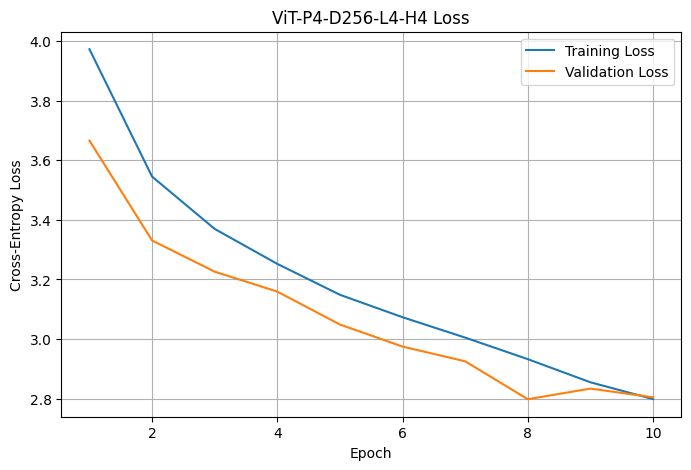

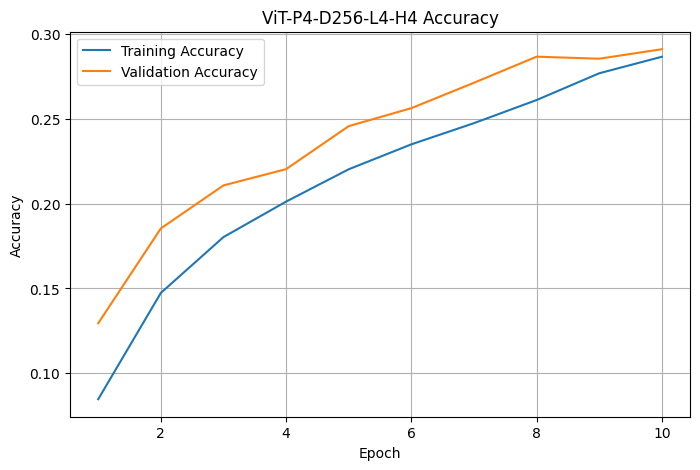

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,3.973026,3.666227,0.084578,0.1294,4.403060,0.201682,4.605400
1,2,3.545261,3.330717,0.147333,0.1854,3.990473,0.212631,4.203520
2,3,3.369484,3.225956,0.180289,0.2108,3.984581,0.216316,4.201535
3,4,3.252092,3.159000,0.201244,0.2204,3.971985,0.206460,4.179179
4,5,3.148327,3.048471,0.220333,0.2458,3.933350,0.216744,4.150779
5,6,3.072971,2.974411,0.235044,0.2564,3.930714,0.208648,4.140117
6,7,3.004518,2.924888,0.247556,0.2714,3.907501,0.211252,4.119410
7,8,2.932105,2.797642,0.261200,0.2868,3.893160,0.207758,4.101491
8,9,2.854472,2.833360,0.277000,0.2856,3.906996,0.207272,4.114830
9,10,2.798038,2.804013,0.286756,0.2912,3.892983,0.204715,4.098165


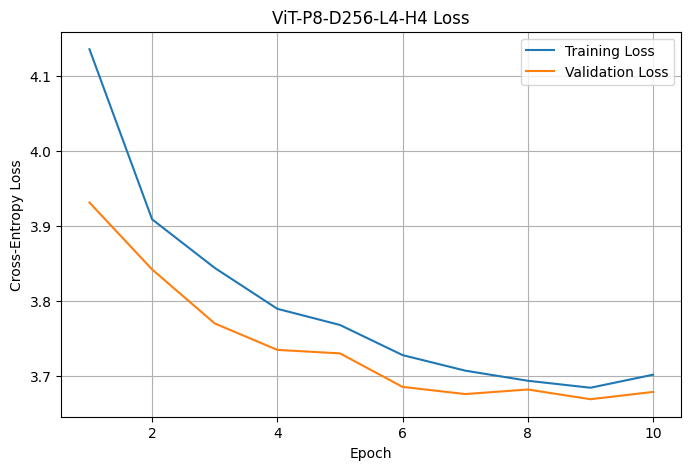

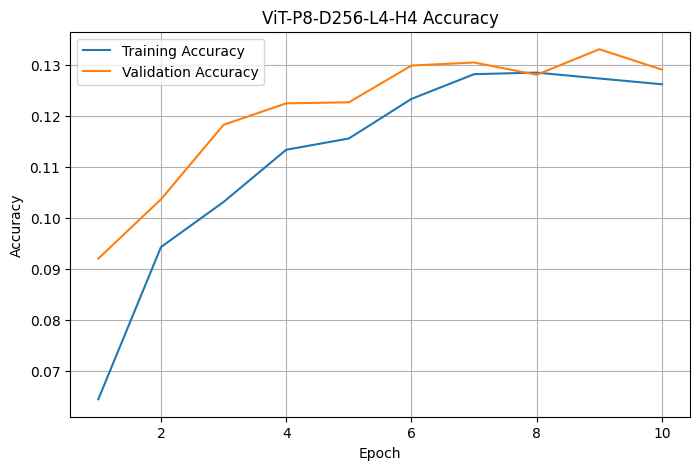

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,4.135112,3.931042,0.064444,0.0920,3.176103,0.207951,3.384676
1,2,3.908734,3.842053,0.094244,0.1036,3.282865,0.203565,3.487050
2,3,3.844072,3.770166,0.103089,0.1182,3.298913,0.203264,3.503007
3,4,3.789632,3.734945,0.113311,0.1224,3.499409,0.191373,3.691688
4,5,3.768114,3.730293,0.115511,0.1226,3.205318,0.195108,3.401319
5,6,3.727997,3.685693,0.123267,0.1298,3.207114,0.204177,3.412115
6,7,3.707323,3.676175,0.128111,0.1304,3.534516,0.193489,3.728883
7,8,3.693850,3.682214,0.128422,0.1280,3.634572,0.194099,3.829499
8,9,3.684569,3.669287,0.127267,0.1330,3.573306,0.213138,3.787028
9,10,3.701931,3.679016,0.126133,0.1290,3.460757,0.194145,3.655833


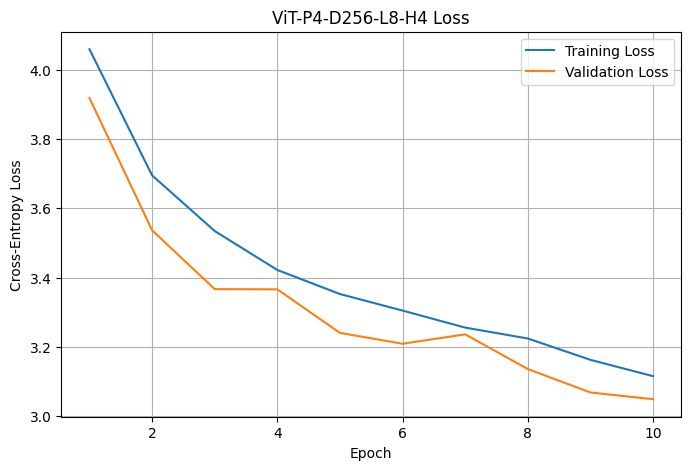

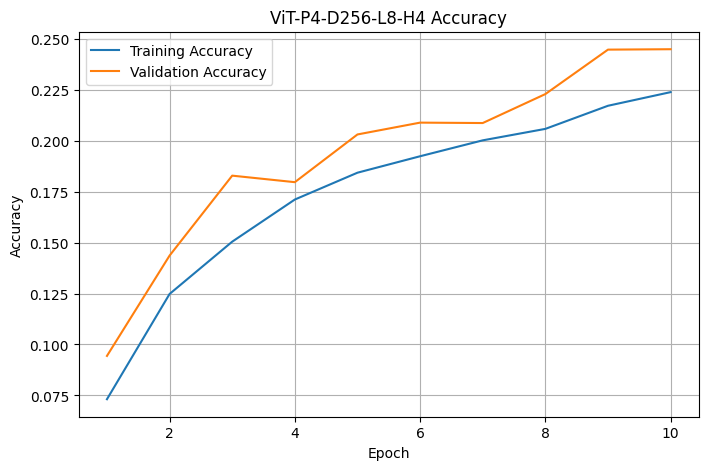

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,4.060283,3.919306,0.073156,0.0944,6.906036,0.358661,7.265471
1,2,3.695444,3.536720,0.124778,0.1436,6.921952,0.345563,7.268406
2,3,3.534524,3.366485,0.150422,0.1828,6.892827,0.356176,7.250226
3,4,3.421873,3.365847,0.171089,0.1796,6.903354,0.344225,7.248558
4,5,3.352313,3.239902,0.184244,0.2030,6.893190,0.351962,7.245790
5,6,3.304440,3.208478,0.192311,0.2088,6.925518,0.349438,7.275999
6,7,3.255201,3.235736,0.200111,0.2086,6.882788,0.354285,7.238018
7,8,3.223716,3.135340,0.205733,0.2228,6.911582,0.353528,7.265811
8,9,3.161979,3.067595,0.217067,0.2446,6.875727,0.351304,7.228009
9,10,3.114723,3.048133,0.223756,0.2448,6.884584,0.354128,7.239688


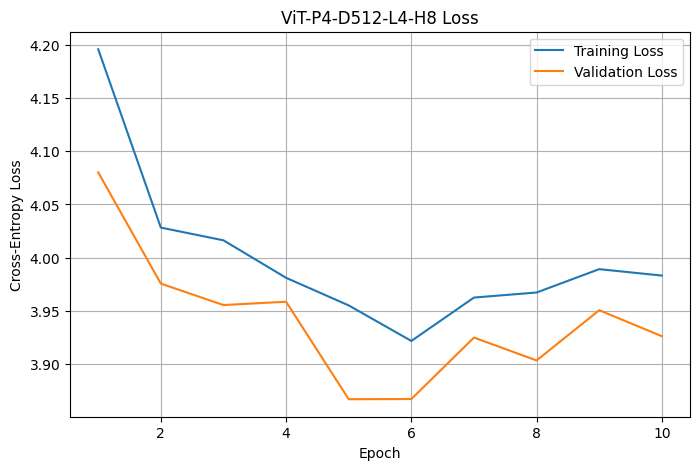

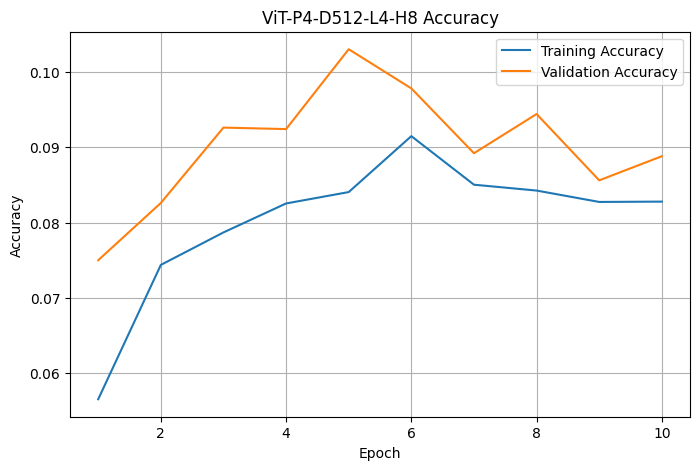

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,4.195676,4.080141,0.056556,0.0750,7.140485,0.347995,7.489100
1,2,4.028326,3.975766,0.074378,0.0826,7.166873,0.339868,7.507698
2,3,4.016389,3.955668,0.078689,0.0926,7.213821,0.340309,7.554774
3,4,3.981226,3.958774,0.082533,0.0924,7.131126,0.342731,7.474806
4,5,3.955326,3.867316,0.084044,0.1030,7.129023,0.343707,7.473648
5,6,3.921987,3.867486,0.091467,0.0978,7.128095,0.351946,7.480758
6,7,3.962692,3.925147,0.085022,0.0892,7.117957,0.344812,7.463435
7,8,3.967434,3.903692,0.084244,0.0944,7.122998,0.352667,7.476166
8,9,3.989339,3.950808,0.082733,0.0856,7.141937,0.359717,7.502296
9,10,3.983313,3.926430,0.082778,0.0888,7.117814,0.350452,7.468804


In [49]:
# 53. Problem 1A Results
PROBLEM1_VIT_TABLE = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "history"
    }
    for result in PROBLEM1_VIT_RESULTS
])

display(PROBLEM1_VIT_TABLE)

for result in PROBLEM1_VIT_RESULTS:
    display(display_history(result))


# 54. Problem 1B: ResNet-18 Baseline and Comparison

In [50]:
# 55. ResNet-18 Model
def create_resnet18_cifar100():
    model = models.resnet18(
        weights=None
    )

    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    model.fc = nn.Linear(
        model.fc.in_features,
        COMMON_CONFIG["num_classes"]
    )

    return model


In [51]:
# 56. ResNet-18 Shape Verification
resnet_shape_model = (
    create_resnet18_cifar100()
).to(DEVICE)

resnet_shape_output = (
    resnet_shape_model(
        torch.randn(
            2,
            3,
            32,
            32,
            device=DEVICE
        )
    )
)

print(
    "Output Shape:",
    resnet_shape_output.shape
)

del resnet_shape_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Output Shape: torch.Size([2, 100])


In [52]:
# 57. ResNet-18 Complexity
resnet_complexity_model = (
    create_resnet18_cifar100()
)

RESNET_PARAMETER_RESULT = (
    count_parameters(
        resnet_complexity_model
    )
)

RESNET_FLOP_RESULT = (
    calculate_supported_flops(
        resnet_complexity_model,
        (1, 3, 32, 32)
    )
)

pd.DataFrame([{
    "Model": "ResNet-18",
    **RESNET_PARAMETER_RESULT,
    **RESNET_FLOP_RESULT,
}])


,Model,total_parameters,trainable_parameters,frozen_parameters,model_size_mb,estimated_flops,flop_method,unsupported_operations
0,ResNet-18,11220132,11220132,0,42.801407,556705792,fvcore supported operations,{'aten::add_': 8}


In [53]:
# 58. ResNet-18 Training
set_all_seeds(SEED)

RESNET_MODEL, RESNET_RESULT = (
    run_classification_experiment(
        model=create_resnet18_cifar100(),
        model_name="ResNet-18",
        model_family=(
            "Convolutional Neural Network"
        ),
        training_mode="Scratch",
        training_loader=P1_TRAIN_LOADER,
        clean_training_loader=(
            P1_CLEAN_TRAIN_LOADER
        ),
        validation_loader=(
            P1_VALIDATION_LOADER
        ),
        test_loader=P1_TEST_LOADER,
        epochs=PROBLEM1_CONFIG[
            "epochs"
        ],
        learning_rate=(
            PROBLEM1_CONFIG[
                "learning_rate"
            ]
        ),
        input_shape=(1, 3, 32, 32),
        configuration={},
        flop_result=RESNET_FLOP_RESULT
    )
)


ResNet-18 | Epoch 01/10 | Train Loss 3.8221 | Val Loss 3.3255 | Train Acc 0.1080 | Val Acc 0.1772 | Train Time 4.52s | Complete Time 4.76s
ResNet-18 | Epoch 02/10 | Train Loss 3.0253 | Val Loss 2.7678 | Train Acc 0.2413 | Val Acc 0.2960 | Train Time 4.34s | Complete Time 4.59s
ResNet-18 | Epoch 03/10 | Train Loss 2.5594 | Val Loss 2.6063 | Train Acc 0.3338 | Val Acc 0.3394 | Train Time 4.29s | Complete Time 4.55s
ResNet-18 | Epoch 04/10 | Train Loss 2.2343 | Val Loss 2.2866 | Train Acc 0.4012 | Val Acc 0.3974 | Train Time 4.31s | Complete Time 4.56s
ResNet-18 | Epoch 05/10 | Train Loss 1.9894 | Val Loss 1.9851 | Train Acc 0.4551 | Val Acc 0.4654 | Train Time 4.33s | Complete Time 4.57s
ResNet-18 | Epoch 06/10 | Train Loss 1.7836 | Val Loss 1.8259 | Train Acc 0.5035 | Val Acc 0.5102 | Train Time 4.31s | Complete Time 4.55s
ResNet-18 | Epoch 07/10 | Train Loss 1.6165 | Val Loss 1.7753 | Train Acc 0.5447 | Val Acc 0.5174 | Train Time 4.30s | Complete Time 4.55s
ResNet-18 | Epoch 08/10 | T

In [54]:
# 59. ResNet-18 Checkpoint Selection
pd.DataFrame([{
    "Best Validation-Loss Epoch": (
        RESNET_RESULT[
            "best_validation_loss_epoch"
        ]
    ),
    "Best Validation Loss": (
        RESNET_RESULT[
            "best_validation_loss"
        ]
    ),
    "Validation Accuracy at Best Loss": (
        RESNET_RESULT[
            "validation_accuracy_at_best_loss"
        ]
    ),
    "Best Validation-Accuracy Epoch": (
        RESNET_RESULT[
            "best_validation_accuracy_epoch"
        ]
    ),
    "Best Validation Accuracy": (
        RESNET_RESULT[
            "best_validation_accuracy"
        ]
    ),
    "Validation Loss at Best Accuracy": (
        RESNET_RESULT[
            "validation_loss_at_best_accuracy"
        ]
    ),
}])


,Best Validation-Loss Epoch,Best Validation Loss,Validation Accuracy at Best Loss,Best Validation-Accuracy Epoch,Best Validation Accuracy,Validation Loss at Best Accuracy
0,9,1.555851,0.5752,9,0.5752,1.555851


In [55]:
# 60. ResNet-18 Final Evaluation
pd.DataFrame([{
    key: value
    for key, value in RESNET_RESULT.items()
    if key != "history"
}])


,model_name,model_family,training_mode,patch_size,embedding_dimension,transformer_blocks,attention_heads,mlp_dimension,total_parameters,trainable_parameters,...,clean_generalization_gap,test_loss,test_accuracy,top5_accuracy,mean_training_time_per_epoch,mean_validation_time_per_epoch,mean_complete_epoch_time,total_training_time,total_experiment_time,learning_status
0,ResNet-18,Convolutional Neural Network,Scratch,NaN,NaN,NaN,NaN,NaN,11220132,11220132,...,0.083089,1.566494,0.5722,0.8524,4.329855,0.243857,4.574331,43.298554,45.743308,Overfitting after best validation-loss epoch


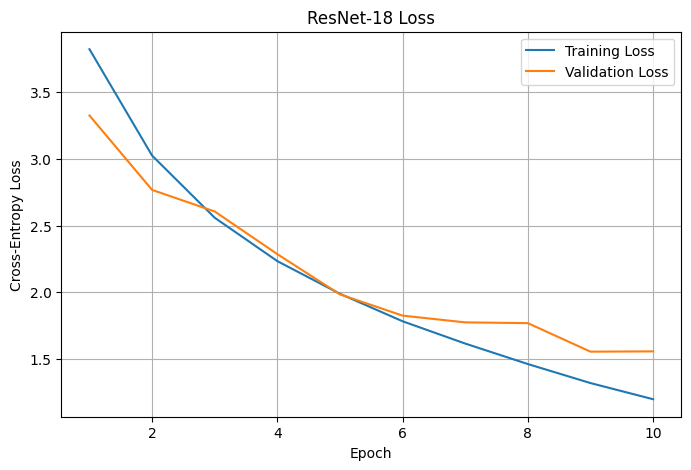

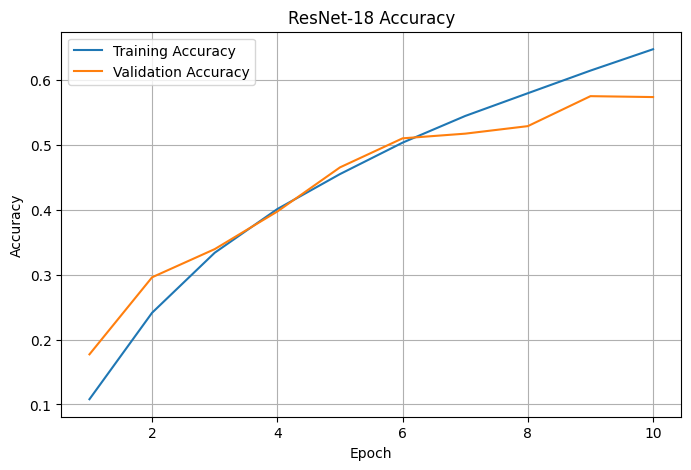

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,3.822131,3.325525,0.108022,0.1772,4.519936,0.235221,4.755670
1,2,3.025334,2.767847,0.241311,0.2960,4.342271,0.249757,4.592500
2,3,2.559372,2.606343,0.333822,0.3394,4.294281,0.255675,4.550577
3,4,2.234284,2.286648,0.401178,0.3974,4.309959,0.248056,4.558645
4,5,1.989449,1.985147,0.455067,0.4654,4.329652,0.239779,4.570134
5,6,1.783588,1.825909,0.503533,0.5102,4.312368,0.232925,4.546004
6,7,1.616529,1.775297,0.544667,0.5174,4.299683,0.250223,4.550654
7,8,1.463058,1.769497,0.579733,0.5290,4.329667,0.239871,4.570245
8,9,1.320538,1.555851,0.614622,0.5752,4.281871,0.249829,4.532369
9,10,1.199450,1.557977,0.647556,0.5738,4.278865,0.237235,4.516510


In [56]:
# 61. ResNet-18 History
display_history(RESNET_RESULT)


In [57]:
# 62. Problem 1 Combined Table
PROBLEM1_RESNET_RESULTS = [
    RESNET_RESULT
]

PROBLEM1_RESULTS = (
    PROBLEM1_VIT_RESULTS
    + PROBLEM1_RESNET_RESULTS
)

PROBLEM1_TABLE = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "history"
    }
    for result in PROBLEM1_RESULTS
])

PROBLEM1_TABLE


,model_name,model_family,training_mode,patch_size,embedding_dimension,transformer_blocks,attention_heads,mlp_dimension,total_parameters,trainable_parameters,...,clean_generalization_gap,test_loss,test_accuracy,top5_accuracy,mean_training_time_per_epoch,mean_validation_time_per_epoch,mean_complete_epoch_time,total_training_time,total_experiment_time,learning_status
0,ViT-P4-D256-L4-H4,Vision Transformer,Scratch,4.0,256.0,4.0,4.0,1024.0,3214692,3214692,...,0.017933,2.817047,0.2840,0.5973,3.981480,0.209348,4.191443,39.814803,41.914426,Overfitting after best validation-loss epoch
1,ViT-P8-D256-L4-H4,Vision Transformer,Scratch,8.0,256.0,4.0,4.0,1024.0,3239268,3239268,...,-0.003867,3.704138,0.1200,0.3590,3.387287,0.200031,3.588110,33.872873,35.881099,Stable or mixed convergence
2,ViT-P4-D256-L8-H4,Vision Transformer,Scratch,4.0,256.0,8.0,4.0,1024.0,6373732,6373732,...,0.010267,3.081597,0.2397,0.5315,6.899756,0.351927,7.252598,68.997559,72.525977,Still converging at final epoch
3,ViT-P4-D512-L4-H8,Vision Transformer,Scratch,4.0,512.0,4.0,8.0,2048.0,12720740,12720740,...,-0.004733,3.871615,0.0994,0.3057,7.141013,0.347420,7.489148,71.410129,74.891484,Stable or mixed convergence
4,ResNet-18,Convolutional Neural Network,Scratch,NaN,NaN,NaN,NaN,NaN,11220132,11220132,...,0.083089,1.566494,0.5722,0.8524,4.329855,0.243857,4.574331,43.298554,45.743308,Overfitting after best validation-loss epoch


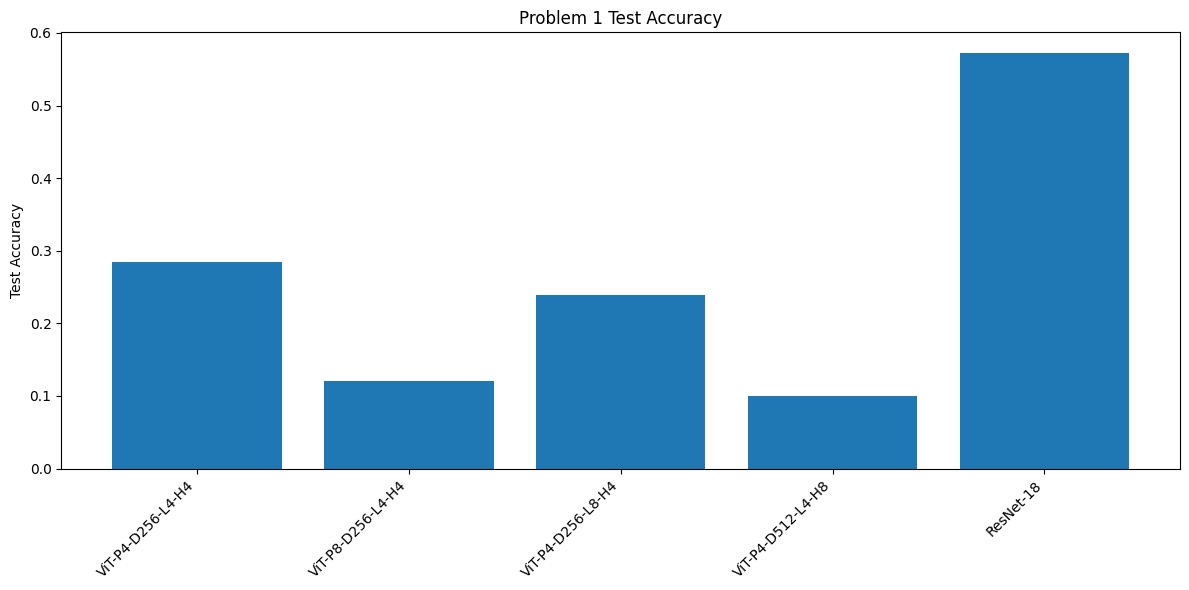

In [58]:
# 63. Accuracy Comparison
plot_result_metric(
    PROBLEM1_RESULTS,
    "test_accuracy",
    "Problem 1 Test Accuracy",
    "Test Accuracy"
)


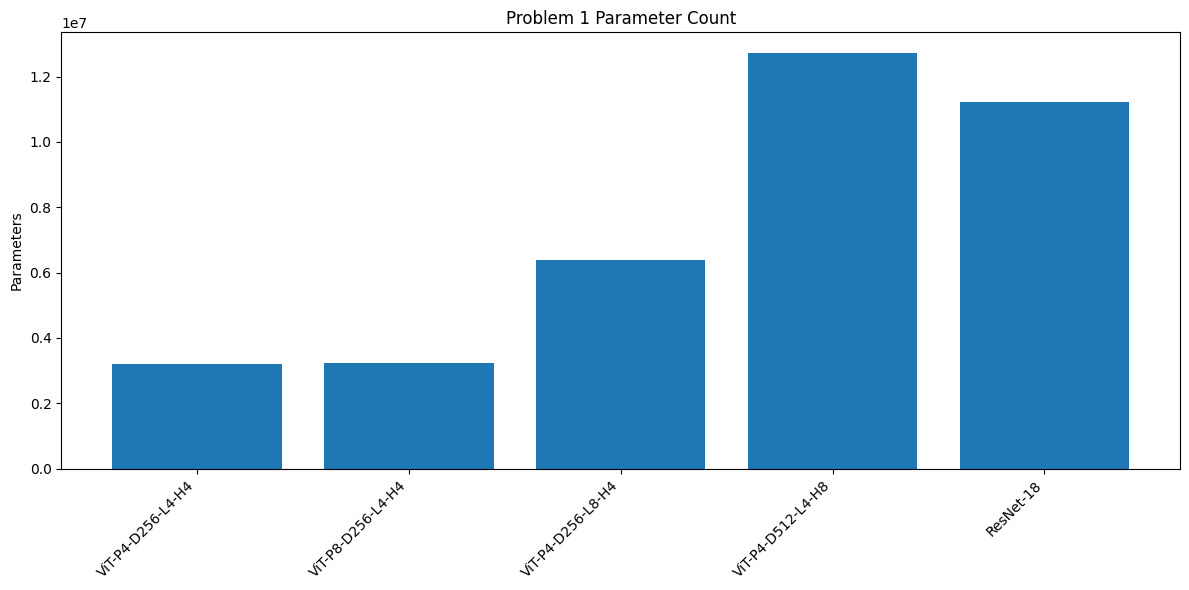

In [59]:
# 64. Parameter Comparison
plot_result_metric(
    PROBLEM1_RESULTS,
    "total_parameters",
    "Problem 1 Parameter Count",
    "Parameters"
)


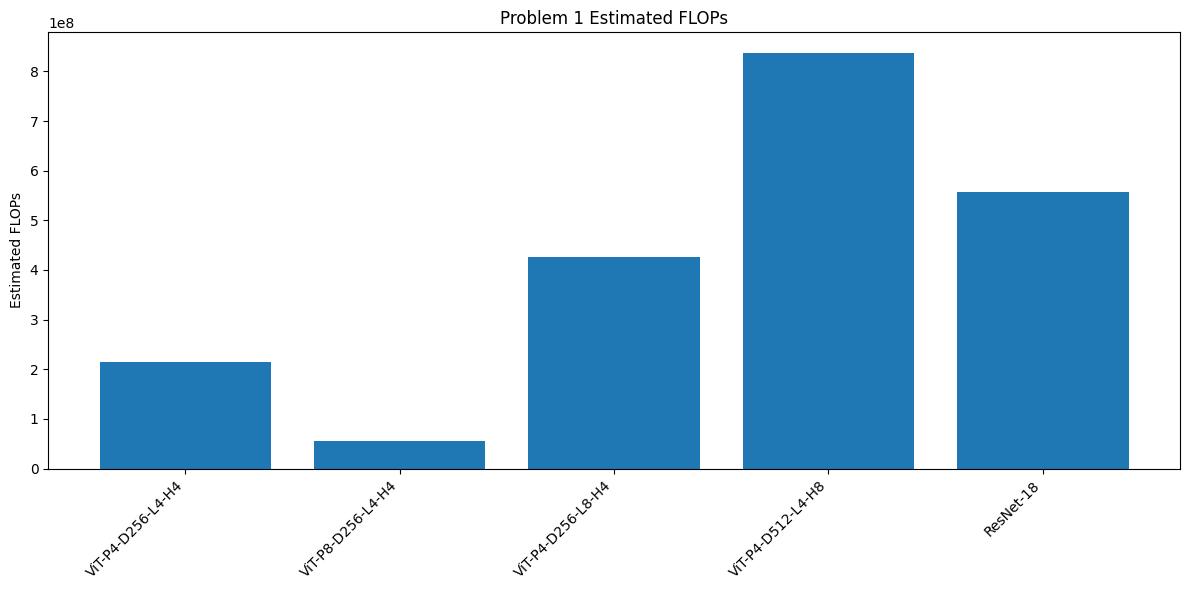

In [60]:
# 65. FLOP Comparison
plot_result_metric(
    PROBLEM1_RESULTS,
    "estimated_flops",
    "Problem 1 Estimated FLOPs",
    "Estimated FLOPs"
)


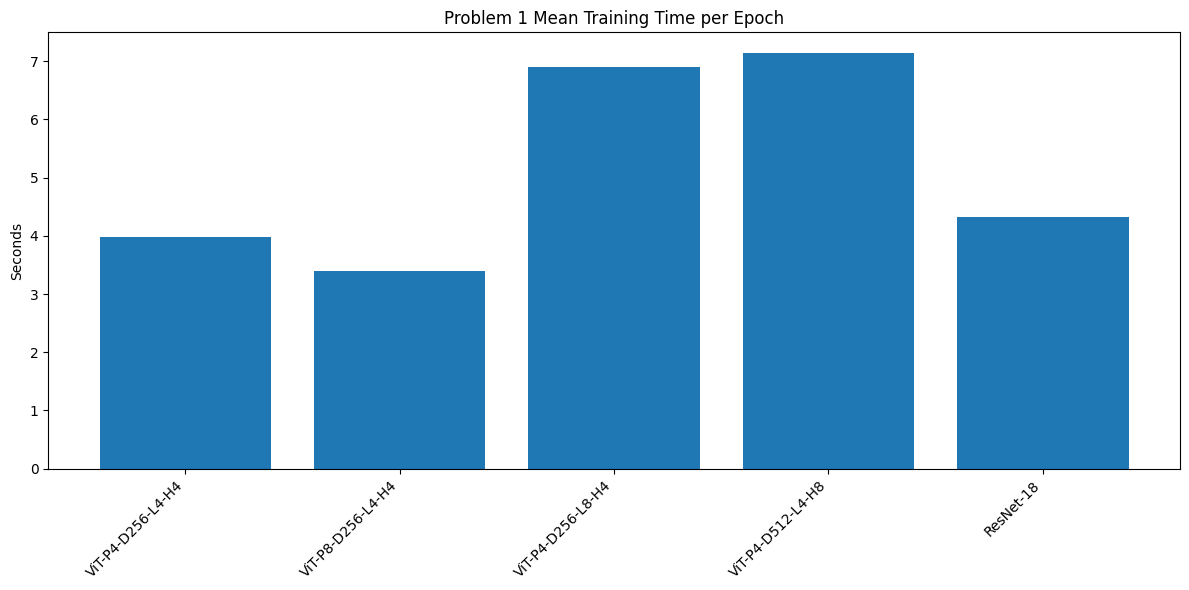

In [61]:
# 66. Training-Time Comparison
plot_result_metric(
    PROBLEM1_RESULTS,
    "mean_training_time_per_epoch",
    "Problem 1 Mean Training Time per Epoch",
    "Seconds"
)


In [62]:
# 67. Best Problem 1 Model
BEST_PROBLEM1_MODEL = max(
    PROBLEM1_RESULTS,
    key=lambda result: result[
        "best_validation_accuracy"
    ]
)

pd.DataFrame([{
    key: value
    for key, value in BEST_PROBLEM1_MODEL.items()
    if key != "history"
}])


,model_name,model_family,training_mode,patch_size,embedding_dimension,transformer_blocks,attention_heads,mlp_dimension,total_parameters,trainable_parameters,...,clean_generalization_gap,test_loss,test_accuracy,top5_accuracy,mean_training_time_per_epoch,mean_validation_time_per_epoch,mean_complete_epoch_time,total_training_time,total_experiment_time,learning_status
0,ResNet-18,Convolutional Neural Network,Scratch,NaN,NaN,NaN,NaN,NaN,11220132,11220132,...,0.083089,1.566494,0.5722,0.8524,4.329855,0.243857,4.574331,43.298554,45.743308,Overfitting after best validation-loss epoch


In [63]:
# 68. Problem 1 Generalization Gap
pd.DataFrame([
    {
        "Model": result["model_name"],
        "Clean Training Accuracy": (
            result[
                "clean_training_accuracy"
            ]
        ),
        "Selected Validation Accuracy": (
            result[
                "selected_validation_accuracy"
            ]
        ),
        "Clean Generalization Gap": (
            result[
                "clean_generalization_gap"
            ]
        ),
        "Learning Status": (
            result["learning_status"]
        ),
    }
    for result in PROBLEM1_RESULTS
])


,Model,Clean Training Accuracy,Selected Validation Accuracy,Clean Generalization Gap,Learning Status
0,ViT-P4-D256-L4-H4,0.304733,0.2868,0.017933,Overfitting after best validation-loss epoch
1,ViT-P8-D256-L4-H4,0.129133,0.1330,-0.003867,Stable or mixed convergence
2,ViT-P4-D256-L8-H4,0.255067,0.2448,0.010267,Still converging at final epoch
3,ViT-P4-D512-L4-H8,0.098267,0.1030,-0.004733,Stable or mixed convergence
4,ResNet-18,0.658289,0.5752,0.083089,Overfitting after best validation-loss epoch


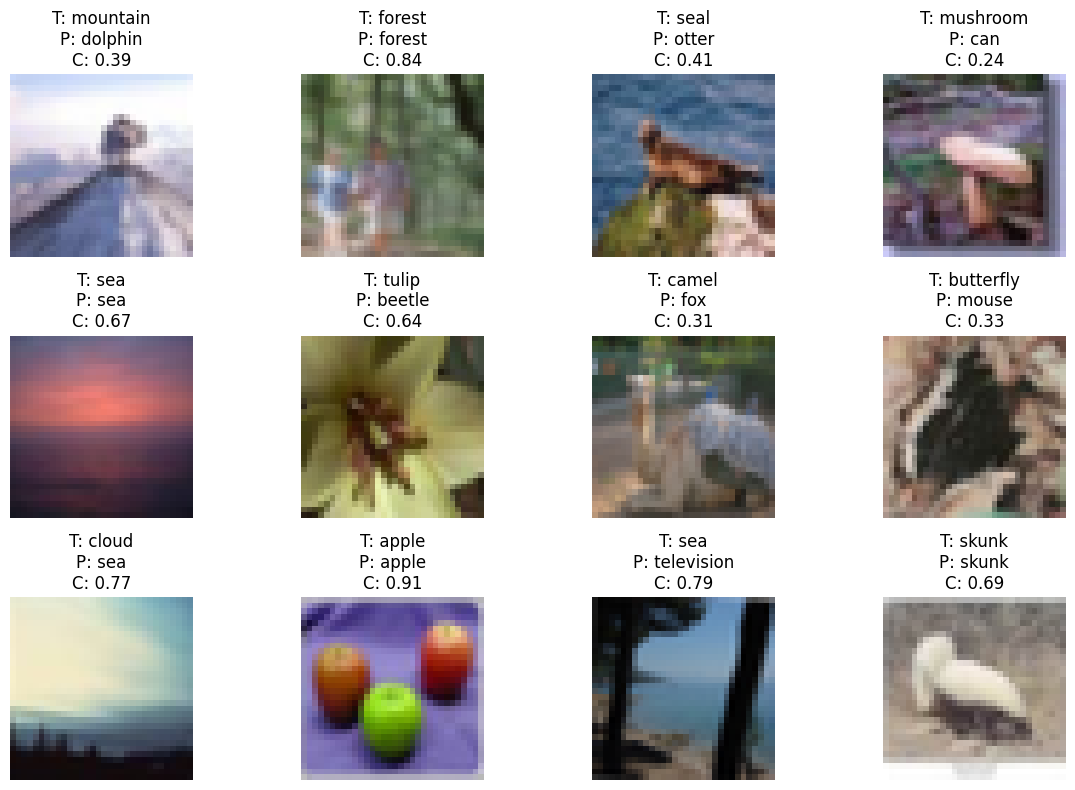

In [64]:
# 69. Problem 1 Qualitative Results
best_problem1_name = (
    BEST_PROBLEM1_MODEL["model_name"]
)

if best_problem1_name == "ResNet-18":
    best_problem1_model = (
        RESNET_MODEL.to(DEVICE)
    )
else:
    best_problem1_model = (
        PROBLEM1_VIT_MODELS[
            best_problem1_name
        ].to(DEVICE)
    )

display_predictions_on_indices(
    best_problem1_model,
    RAW_TEST_DATASET,
    QUALITATIVE_INDICES,
    P1_EVAL_TRANSFORM
)


# 70. Problem 2: Pretrained Swin Transformers vs. Scratch Swin

In [65]:
# 71. Swin Model Checkpoints
pd.DataFrame([{
    "Tiny Checkpoint": SWIN_TINY_CHECKPOINT,
    "Small Checkpoint": SWIN_SMALL_CHECKPOINT,
    "Image Size": SWIN_IMAGE_SIZE,
    "Mean": SWIN_MEAN,
    "Standard Deviation": SWIN_STD,
}])


,Tiny Checkpoint,Small Checkpoint,Image Size,Mean,Standard Deviation
0,microsoft/swin-tiny-patch4-window7-224,microsoft/swin-small-patch4-window7-224,"(224, 224)","(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)"


In [66]:
# 72. Pretrained Swin Factory
CIFAR100_ID2LABEL = {
    index: name
    for index, name
    in enumerate(CLASS_NAMES)
}

CIFAR100_LABEL2ID = {
    name: index
    for index, name
    in CIFAR100_ID2LABEL.items()
}


def freeze_swin_backbone(model):
    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in (
        model.classifier.parameters()
    ):
        parameter.requires_grad = True

    return model


def get_trainable_parameter_names(
    model
):
    return [
        name
        for name, parameter
        in model.named_parameters()
        if parameter.requires_grad
    ]


def get_huggingface_swin_metadata(
    model
):
    config = model.config

    return {
        "patch_size": config.patch_size,
        "embedding_dimension": (
            config.embed_dim
        ),
        "transformer_blocks": sum(
            config.depths
        ),
        "attention_heads": str(
            list(config.num_heads)
        ),
        "mlp_dimension": (
            int(
                config.embed_dim
                * (
                    2
                    ** (
                        len(config.depths)
                        - 1
                    )
                )
                * config.mlp_ratio
            )
        ),
    }


def create_pretrained_swin(
    checkpoint
):
    model = (
        SwinForImageClassification
        .from_pretrained(
            checkpoint,
            num_labels=COMMON_CONFIG[
                "num_classes"
            ],
            id2label=CIFAR100_ID2LABEL,
            label2id=CIFAR100_LABEL2ID,
            ignore_mismatched_sizes=True
        )
    )

    model = freeze_swin_backbone(
        model
    )

    trainable_names = (
        get_trainable_parameter_names(
            model
        )
    )

    assert len(trainable_names) > 0

    assert all(
        name.startswith("classifier")
        for name in trainable_names
    )

    return model


In [67]:
# 73. Scratch Swin Window Functions
class DropPath(nn.Module):
    def __init__(self, probability=0.0):
        super().__init__()
        self.probability = probability

    def forward(self, x):
        if (
            self.probability == 0.0
            or not self.training
        ):
            return x

        keep_probability = (
            1.0 - self.probability
        )

        shape = (
            x.shape[0],
            *([1] * (x.ndim - 1))
        )

        random_tensor = (
            keep_probability
            + torch.rand(
                shape,
                dtype=x.dtype,
                device=x.device
            )
        )

        random_tensor.floor_()

        return (
            x
            / keep_probability
            * random_tensor
        )


def window_partition(
    x,
    window_size
):
    batch_size, height, width, channels = (
        x.shape
    )

    x = x.view(
        batch_size,
        height // window_size,
        window_size,
        width // window_size,
        window_size,
        channels
    )

    windows = x.permute(
        0,
        1,
        3,
        2,
        4,
        5
    ).contiguous()

    windows = windows.view(
        -1,
        window_size * window_size,
        channels
    )

    return windows


def window_reverse(
    windows,
    window_size,
    height,
    width
):
    batch_size = int(
        windows.shape[0]
        / (
            height
            * width
            / window_size
            / window_size
        )
    )

    x = windows.view(
        batch_size,
        height // window_size,
        width // window_size,
        window_size,
        window_size,
        -1
    )

    x = x.permute(
        0,
        1,
        3,
        2,
        4,
        5
    ).contiguous()

    return x.view(
        batch_size,
        height,
        width,
        -1
    )


In [68]:
# 74. Scratch Swin Patch Layers
class SwinPatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=4,
        input_channels=3,
        embedding_dimension=96
    ):
        super().__init__()

        self.grid_size = (
            image_size // patch_size,
            image_size // patch_size
        )

        self.projection = nn.Conv2d(
            input_channels,
            embedding_dimension,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.norm = nn.LayerNorm(
            embedding_dimension
        )

    def forward(self, images):
        x = self.projection(images)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        return x


class PatchMerging(nn.Module):
    def __init__(self, dimension):
        super().__init__()

        self.norm = nn.LayerNorm(
            4 * dimension
        )

        self.reduction = nn.Linear(
            4 * dimension,
            2 * dimension,
            bias=False
        )

    def forward(self, x):
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat(
            [x0, x1, x2, x3],
            dim=-1
        )

        x = self.norm(x)
        x = self.reduction(x)

        return x


In [69]:
# 75. Scratch Swin Window Attention
class WindowAttention(nn.Module):
    def __init__(
        self,
        dimension,
        window_size,
        attention_heads,
        attention_dropout=0.0,
        projection_dropout=0.0
    ):
        super().__init__()

        self.dimension = dimension
        self.window_size = window_size
        self.attention_heads = (
            attention_heads
        )

        head_dimension = (
            dimension // attention_heads
        )

        self.scale = (
            head_dimension ** -0.5
        )

        relative_bias_size = (
            2 * window_size - 1
        ) ** 2

        self.relative_position_bias_table = (
            nn.Parameter(
                torch.zeros(
                    relative_bias_size,
                    attention_heads
                )
            )
        )

        coordinate_values = torch.arange(
            window_size
        )

        coordinates = torch.stack(
            torch.meshgrid(
                coordinate_values,
                coordinate_values,
                indexing="ij"
            )
        )

        coordinates_flat = (
            coordinates.flatten(1)
        )

        relative_coordinates = (
            coordinates_flat[:, :, None]
            - coordinates_flat[:, None, :]
        )

        relative_coordinates = (
            relative_coordinates.permute(
                1,
                2,
                0
            ).contiguous()
        )

        relative_coordinates[:, :, 0] += (
            window_size - 1
        )

        relative_coordinates[:, :, 1] += (
            window_size - 1
        )

        relative_coordinates[:, :, 0] *= (
            2 * window_size - 1
        )

        relative_position_index = (
            relative_coordinates.sum(-1)
        )

        self.register_buffer(
            "relative_position_index",
            relative_position_index
        )

        self.qkv = nn.Linear(
            dimension,
            dimension * 3,
            bias=True
        )

        self.attention_dropout = nn.Dropout(
            attention_dropout
        )

        self.projection = nn.Linear(
            dimension,
            dimension
        )

        self.projection_dropout = nn.Dropout(
            projection_dropout
        )

        nn.init.trunc_normal_(
            self.relative_position_bias_table,
            std=0.02
        )

    def forward(
        self,
        x,
        attention_mask=None
    ):
        batch_windows, tokens, channels = (
            x.shape
        )

        qkv = self.qkv(x).reshape(
            batch_windows,
            tokens,
            3,
            self.attention_heads,
            channels // self.attention_heads
        ).permute(
            2,
            0,
            3,
            1,
            4
        )

        query, key, value = (
            qkv[0],
            qkv[1],
            qkv[2]
        )

        query = query * self.scale

        attention = (
            query
            @ key.transpose(-2, -1)
        )

        relative_bias = (
            self.relative_position_bias_table[
                self.relative_position_index
                .reshape(-1)
            ]
        )

        relative_bias = relative_bias.view(
            tokens,
            tokens,
            -1
        ).permute(
            2,
            0,
            1
        ).contiguous()

        attention = (
            attention
            + relative_bias.unsqueeze(0)
        )

        if attention_mask is not None:
            number_of_windows = (
                attention_mask.shape[0]
            )

            attention = attention.view(
                batch_windows
                // number_of_windows,
                number_of_windows,
                self.attention_heads,
                tokens,
                tokens
            )

            attention = (
                attention
                + attention_mask.unsqueeze(
                    0
                ).unsqueeze(2)
            )

            attention = attention.view(
                -1,
                self.attention_heads,
                tokens,
                tokens
            )

        attention = torch.softmax(
            attention,
            dim=-1
        )

        attention = (
            self.attention_dropout(
                attention
            )
        )

        x = attention @ value

        x = x.transpose(
            1,
            2
        ).reshape(
            batch_windows,
            tokens,
            channels
        )

        x = self.projection(x)
        x = self.projection_dropout(x)

        return x


In [70]:
# 76. Scratch Swin Block
class SwinMLP(nn.Module):
    def __init__(
        self,
        dimension,
        mlp_ratio=4.0,
        dropout=0.0
    ):
        super().__init__()

        hidden_dimension = int(
            dimension * mlp_ratio
        )

        self.network = nn.Sequential(
            nn.Linear(
                dimension,
                hidden_dimension
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                hidden_dimension,
                dimension
            ),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.network(x)


class SwinBlock(nn.Module):
    def __init__(
        self,
        dimension,
        input_resolution,
        attention_heads,
        window_size=7,
        shift_size=0,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0,
        drop_path=0.0
    ):
        super().__init__()

        self.dimension = dimension
        self.input_resolution = (
            input_resolution
        )
        self.window_size = window_size
        self.shift_size = shift_size

        height, width = input_resolution

        assert (
            height % window_size == 0
            and width % window_size == 0
        )

        self.norm1 = nn.LayerNorm(
            dimension
        )

        self.attention = WindowAttention(
            dimension,
            window_size,
            attention_heads,
            attention_dropout,
            dropout
        )

        self.drop_path = DropPath(
            drop_path
        )

        self.norm2 = nn.LayerNorm(
            dimension
        )

        self.mlp = SwinMLP(
            dimension,
            mlp_ratio,
            dropout
        )

        if shift_size > 0:
            image_mask = torch.zeros(
                1,
                height,
                width,
                1
            )

            height_slices = (
                slice(
                    0,
                    -window_size
                ),
                slice(
                    -window_size,
                    -shift_size
                ),
                slice(
                    -shift_size,
                    None
                ),
            )

            width_slices = (
                slice(
                    0,
                    -window_size
                ),
                slice(
                    -window_size,
                    -shift_size
                ),
                slice(
                    -shift_size,
                    None
                ),
            )

            count = 0

            for height_slice in height_slices:
                for width_slice in width_slices:
                    image_mask[
                        :,
                        height_slice,
                        width_slice,
                        :
                    ] = count

                    count += 1

            mask_windows = window_partition(
                image_mask,
                window_size
            ).squeeze(-1)

            attention_mask = (
                mask_windows.unsqueeze(1)
                - mask_windows.unsqueeze(2)
            )

            attention_mask = (
                attention_mask.masked_fill(
                    attention_mask != 0,
                    float(-100.0)
                ).masked_fill(
                    attention_mask == 0,
                    float(0.0)
                )
            )
        else:
            attention_mask = None

        self.register_buffer(
            "attention_mask",
            attention_mask
        )

    def forward(self, x):
        height, width = (
            self.input_resolution
        )

        shortcut = x
        x = self.norm1(x)

        if self.shift_size > 0:
            shifted_x = torch.roll(
                x,
                shifts=(
                    -self.shift_size,
                    -self.shift_size
                ),
                dims=(1, 2)
            )
        else:
            shifted_x = x

        x_windows = window_partition(
            shifted_x,
            self.window_size
        )

        attention_windows = self.attention(
            x_windows,
            self.attention_mask
        )

        shifted_x = window_reverse(
            attention_windows,
            self.window_size,
            height,
            width
        )

        if self.shift_size > 0:
            x = torch.roll(
                shifted_x,
                shifts=(
                    self.shift_size,
                    self.shift_size
                ),
                dims=(1, 2)
            )
        else:
            x = shifted_x

        x = shortcut + self.drop_path(x)

        x = x + self.drop_path(
            self.mlp(
                self.norm2(x)
            )
        )

        return x


In [71]:
# 77. Scratch Swin Model
class SwinStage(nn.Module):
    def __init__(
        self,
        dimension,
        input_resolution,
        depth,
        attention_heads,
        window_size,
        mlp_ratio,
        dropout,
        attention_dropout,
        drop_path_values,
        downsample
    ):
        super().__init__()

        self.blocks = nn.ModuleList([
            SwinBlock(
                dimension=dimension,
                input_resolution=(
                    input_resolution
                ),
                attention_heads=(
                    attention_heads
                ),
                window_size=window_size,
                shift_size=(
                    0
                    if block_index % 2 == 0
                    else window_size // 2
                ),
                mlp_ratio=mlp_ratio,
                dropout=dropout,
                attention_dropout=(
                    attention_dropout
                ),
                drop_path=(
                    drop_path_values[
                        block_index
                    ]
                )
            )
            for block_index in range(depth)
        ])

        self.downsample = (
            PatchMerging(dimension)
            if downsample
            else nn.Identity()
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)

        x = self.downsample(x)

        return x


class ScratchSwinTransformer(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=4,
        input_channels=3,
        num_classes=100,
        embedding_dimension=96,
        depths=(2, 2, 6, 2),
        attention_heads=(3, 6, 12, 24),
        window_size=7,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0,
        drop_path_rate=0.1
    ):
        super().__init__()

        self.patch_embedding = (
            SwinPatchEmbedding(
                image_size=image_size,
                patch_size=patch_size,
                input_channels=input_channels,
                embedding_dimension=(
                    embedding_dimension
                )
            )
        )

        total_blocks = sum(depths)

        drop_path_values = (
            torch.linspace(
                0,
                drop_path_rate,
                total_blocks
            ).tolist()
        )

        stages = []
        block_offset = 0

        current_dimension = (
            embedding_dimension
        )

        current_resolution = (
            image_size // patch_size,
            image_size // patch_size
        )

        for stage_index in range(
            len(depths)
        ):
            depth = depths[stage_index]

            stage_drop_path_values = (
                drop_path_values[
                    block_offset:
                    block_offset + depth
                ]
            )

            stages.append(
                SwinStage(
                    dimension=(
                        current_dimension
                    ),
                    input_resolution=(
                        current_resolution
                    ),
                    depth=depth,
                    attention_heads=(
                        attention_heads[
                            stage_index
                        ]
                    ),
                    window_size=(
                        window_size
                    ),
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                    attention_dropout=(
                        attention_dropout
                    ),
                    drop_path_values=(
                        stage_drop_path_values
                    ),
                    downsample=(
                        stage_index
                        < len(depths) - 1
                    )
                )
            )

            block_offset += depth

            if stage_index < len(depths) - 1:
                current_dimension *= 2

                current_resolution = (
                    current_resolution[0] // 2,
                    current_resolution[1] // 2
                )

        self.stages = nn.ModuleList(
            stages
        )

        self.norm = nn.LayerNorm(
            current_dimension
        )

        self.classifier = nn.Linear(
            current_dimension,
            num_classes
        )

        self.apply(
            self._initialize_weights
        )

    def _initialize_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(
                module.weight,
                std=0.02
            )

            if module.bias is not None:
                nn.init.zeros_(
                    module.bias
                )

        elif isinstance(
            module,
            nn.LayerNorm
        ):
            nn.init.ones_(
                module.weight
            )

            nn.init.zeros_(
                module.bias
            )

    def forward(self, images):
        x = self.patch_embedding(images)

        for stage in self.stages:
            x = stage(x)

        x = self.norm(x)
        x = x.mean(dim=(1, 2))

        return self.classifier(x)


SCRATCH_SWIN_CONFIGURATION = {
    "patch_size": 4,
    "embedding_dimension": 96,
    "transformer_blocks": 12,
    "attention_heads": 24,
    "mlp_dimension": 3072,
}


def create_scratch_swin():
    return ScratchSwinTransformer(
        image_size=SWIN_IMAGE_SIZE[0],
        patch_size=4,
        input_channels=3,
        num_classes=COMMON_CONFIG[
            "num_classes"
        ],
        embedding_dimension=96,
        depths=(2, 2, 6, 2),
        attention_heads=(3, 6, 12, 24),
        window_size=7,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0,
        drop_path_rate=0.1
    )


In [72]:
# 78. Swin Shape and Frozen-Parameter Verification
swin_tiny_verification_model = (
    create_pretrained_swin(
        SWIN_TINY_CHECKPOINT
    )
)

swin_small_verification_model = (
    create_pretrained_swin(
        SWIN_SMALL_CHECKPOINT
    )
)

scratch_swin_verification_model = (
    create_scratch_swin()
)

verification_rows = []

for model_name, model in {
    "Swin-Tiny Pretrained": (
        swin_tiny_verification_model
    ),
    "Swin-Small Pretrained": (
        swin_small_verification_model
    ),
    "Scratch Swin": (
        scratch_swin_verification_model
    ),
}.items():
    model = model.to(DEVICE)

    with torch.no_grad():
        output = extract_logits(
            model(
                torch.randn(
                    1,
                    3,
                    SWIN_IMAGE_SIZE[0],
                    SWIN_IMAGE_SIZE[1],
                    device=DEVICE
                )
            )
        )

    parameter_result = count_parameters(
        model
    )

    verification_rows.append({
        "Model": model_name,
        "Output Shape": str(
            tuple(output.shape)
        ),
        "Total Parameters": (
            parameter_result[
                "total_parameters"
            ]
        ),
        "Trainable Parameters": (
            parameter_result[
                "trainable_parameters"
            ]
        ),
        "Trainable Names": str(
            get_trainable_parameter_names(
                model
            )[:6]
        ),
    })

    model = model.cpu()

pd.DataFrame(verification_rows)


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


...

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


,Model,Output Shape,Total Parameters,Trainable Parameters,Trainable Names
0,Swin-Tiny Pretrained,"(1, 100)",27596254,76900,"['classifier.weight', 'classifier.bias']"
1,Swin-Small Pretrained,"(1, 100)",48914158,76900,"['classifier.weight', 'classifier.bias']"
2,Scratch Swin,"(1, 100)",27596254,27596254,"['patch_embedding.projection.weight', 'patch_e..."


In [73]:
# 79. Swin Complexity Analysis
SWIN_COMPLEXITY_MODELS = {
    "Swin-Tiny Pretrained": (
        swin_tiny_verification_model
    ),
    "Swin-Small Pretrained": (
        swin_small_verification_model
    ),
    "Scratch Swin": (
        scratch_swin_verification_model
    ),
}

SWIN_FLOP_RESULTS = {}
swin_complexity_rows = []

for model_name, model in (
    SWIN_COMPLEXITY_MODELS.items()
):
    parameter_result = count_parameters(
        model
    )

    flop_result = (
        calculate_supported_flops(
            model,
            (
                1,
                3,
                SWIN_IMAGE_SIZE[0],
                SWIN_IMAGE_SIZE[1]
            )
        )
    )

    SWIN_FLOP_RESULTS[
        model_name
    ] = flop_result

    swin_complexity_rows.append({
        "Model": model_name,
        **parameter_result,
        **flop_result,
    })

SWIN_COMPLEXITY_TABLE = pd.DataFrame(
    swin_complexity_rows
)

SWIN_COMPLEXITY_TABLE


model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

,Model,total_parameters,trainable_parameters,frozen_parameters,model_size_mb,estimated_flops,flop_method,unsupported_operations
0,Swin-Tiny Pretrained,27596254,76900,27519354,105.271355,4368361728,fvcore supported operations,"{'aten::rsub': 20, 'aten::pad': 12, 'aten::sca..."
1,Swin-Small Pretrained,48914158,76900,48837258,186.592705,8539191552,fvcore supported operations,"{'aten::rsub': 44, 'aten::pad': 24, 'aten::sca..."
2,Scratch Swin,27596254,27596254,0,105.271355,4508503296,fvcore supported operations,"{'aten::mul': 12, 'aten::add': 42, 'aten::soft..."


In [74]:
# 80. Swin Experiment Function
PROBLEM2_SWIN_RESULTS = []
PROBLEM2_SWIN_MODELS = {}

def run_swin_experiment(
    model,
    model_name,
    training_mode,
    learning_rate,
    configuration
):
    trained_model, result = (
        run_classification_experiment(
            model=model,
            model_name=model_name,
            model_family=(
                "Swin Transformer"
            ),
            training_mode=training_mode,
            training_loader=(
                P2_TRAIN_LOADER
            ),
            clean_training_loader=(
                P2_CLEAN_TRAIN_LOADER
            ),
            validation_loader=(
                P2_VALIDATION_LOADER
            ),
            test_loader=P2_TEST_LOADER,
            epochs=PROBLEM2_CONFIG[
                "epochs"
            ],
            learning_rate=(
                learning_rate
            ),
            input_shape=(
                1,
                3,
                SWIN_IMAGE_SIZE[0],
                SWIN_IMAGE_SIZE[1]
            ),
            configuration=configuration,
            flop_result=(
                SWIN_FLOP_RESULTS[
                    model_name
                ]
            )
        )
    )

    PROBLEM2_SWIN_RESULTS.append(
        result
    )

    PROBLEM2_SWIN_MODELS[
        model_name
    ] = trained_model

    return result


In [75]:
# 81. Train Pretrained Swin-Tiny
set_all_seeds(SEED)

swin_tiny_training_model = (
    create_pretrained_swin(
        SWIN_TINY_CHECKPOINT
    )
)

SWIN_TINY_RESULT = run_swin_experiment(
    model=swin_tiny_training_model,
    model_name="Swin-Tiny Pretrained",
    training_mode=(
        "Pretrained Frozen Backbone"
    ),
    learning_rate=(
        PROBLEM2_CONFIG[
            "pretrained_learning_rate"
        ]
    ),
    configuration=(
        get_huggingface_swin_metadata(
            swin_tiny_training_model
        )
    )
)


[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Swin-Tiny Pretrained | Epoch 01/05 | Train Loss 4.1033 | Val Loss 3.5485 | Train Acc 0.2250 | Val Acc 0.4796 | Train Time 19.85s | Complete Time 21.98s
Swin-Tiny Pretrained | Epoch 02/05 | Train Loss 3.1308 | Val Loss 2.7063 | Train Acc 0.5534 | Val Acc 0.6154 | Train Time 20.05s | Complete Time 22.19s
Swin-Tiny Pretrained | Epoch 03/05 | Train Loss 2.4257 | Val Loss 2.1285 | Train Acc 0.6312 | Val Acc 0.6606 | Train Time 19.85s | Complete Time 22.00s
Swin-Tiny Pretrained | Epoch 04/05 | Train Loss 1.9564 | Val Loss 1.7600 | Train Acc 0.6625 | Val Acc 0.6798 | Train Time 19.81s | Complete Time 21.96s
Swin-Tiny Pretrained | Epoch 05/05 | Train Loss 1.6585 | Val Loss 1.5281 | Train Acc 0.6817 | Val Acc 0.6972 | Train Time 19.81s | Complete Time 21.97s


In [76]:
# 82. Train Pretrained Swin-Small
set_all_seeds(SEED)

swin_small_training_model = (
    create_pretrained_swin(
        SWIN_SMALL_CHECKPOINT
    )
)

SWIN_SMALL_RESULT = run_swin_experiment(
    model=swin_small_training_model,
    model_name="Swin-Small Pretrained",
    training_mode=(
        "Pretrained Frozen Backbone"
    ),
    learning_rate=(
        PROBLEM2_CONFIG[
            "pretrained_learning_rate"
        ]
    ),
    configuration=(
        get_huggingface_swin_metadata(
            swin_small_training_model
        )
    )
)


[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Swin-Small Pretrained | Epoch 01/05 | Train Loss 4.0261 | Val Loss 3.4179 | Train Acc 0.2804 | Val Acc 0.5344 | Train Time 35.23s | Complete Time 39.00s
Swin-Small Pretrained | Epoch 02/05 | Train Loss 2.9490 | Val Loss 2.4954 | Train Acc 0.6065 | Val Acc 0.6440 | Train Time 35.43s | Complete Time 39.15s
Swin-Small Pretrained | Epoch 03/05 | Train Loss 2.1898 | Val Loss 1.8909 | Train Acc 0.6703 | Val Acc 0.6810 | Train Time 35.15s | Complete Time 38.91s
Swin-Small Pretrained | Epoch 04/05 | Train Loss 1.7152 | Val Loss 1.5326 | Train Acc 0.6992 | Val Acc 0.7000 | Train Time 35.18s | Complete Time 38.95s
Swin-Small Pretrained | Epoch 05/05 | Train Loss 1.4313 | Val Loss 1.3217 | Train Acc 0.7141 | Val Acc 0.7164 | Train Time 34.71s | Complete Time 38.47s


In [77]:
# 83. Train Scratch Swin
set_all_seeds(SEED)

SCRATCH_SWIN_RESULT = run_swin_experiment(
    model=create_scratch_swin(),
    model_name="Scratch Swin",
    training_mode=(
        "Manual Scratch Implementation"
    ),
    learning_rate=(
        PROBLEM2_CONFIG[
            "scratch_learning_rate"
        ]
    ),
    configuration=(
        SCRATCH_SWIN_CONFIGURATION
    )
)


Scratch Swin | Epoch 01/05 | Train Loss 4.6819 | Val Loss 4.6421 | Train Acc 0.0110 | Val Acc 0.0102 | Train Time 58.65s | Complete Time 60.83s
Scratch Swin | Epoch 02/05 | Train Loss 4.6265 | Val Loss 4.6090 | Train Acc 0.0097 | Val Acc 0.0088 | Train Time 58.47s | Complete Time 60.63s
Scratch Swin | Epoch 03/05 | Train Loss 4.6120 | Val Loss 4.6113 | Train Acc 0.0100 | Val Acc 0.0106 | Train Time 58.40s | Complete Time 60.58s
Scratch Swin | Epoch 04/05 | Train Loss 4.6101 | Val Loss 4.6088 | Train Acc 0.0093 | Val Acc 0.0124 | Train Time 58.40s | Complete Time 60.57s
Scratch Swin | Epoch 05/05 | Train Loss 4.6082 | Val Loss 4.6095 | Train Acc 0.0093 | Val Acc 0.0078 | Train Time 58.58s | Complete Time 60.75s


,model_name,model_family,training_mode,patch_size,embedding_dimension,transformer_blocks,attention_heads,mlp_dimension,total_parameters,trainable_parameters,...,clean_generalization_gap,test_loss,test_accuracy,top5_accuracy,mean_training_time_per_epoch,mean_validation_time_per_epoch,mean_complete_epoch_time,total_training_time,total_experiment_time,learning_status
0,Swin-Tiny Pretrained,Swin Transformer,Pretrained Frozen Backbone,4,96,12,"[3, 6, 12, 24]",3072,27596254,76900,...,0.001622,1.548806,0.6806,0.9206,19.871298,2.149051,22.021384,99.356492,110.106921,Still converging at final epoch
1,Swin-Small Pretrained,Swin Transformer,Pretrained Frozen Backbone,4,96,24,"[3, 6, 12, 24]",3072,48914158,76900,...,0.012133,1.339383,0.7187,0.9401,35.140615,3.753728,38.896061,175.703077,194.480303,Still converging at final epoch
2,Scratch Swin,Swin Transformer,Manual Scratch Implementation,4,96,12,24,3072,27596254,27596254,...,-0.002667,4.608573,0.0100,0.0500,58.500361,2.172905,60.674756,292.501807,303.373781,Failed learning / severe underfitting


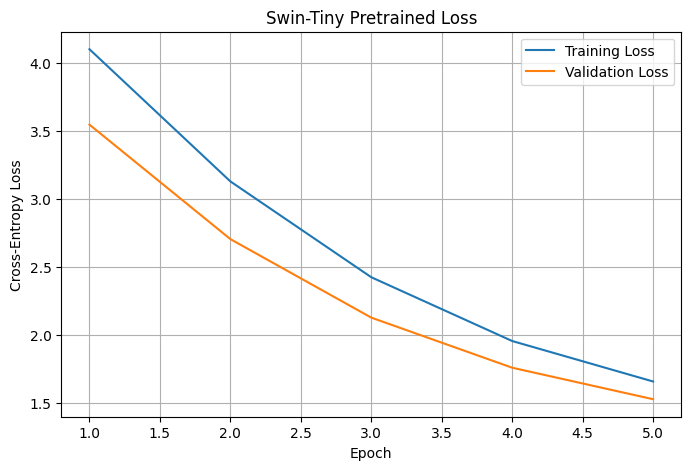

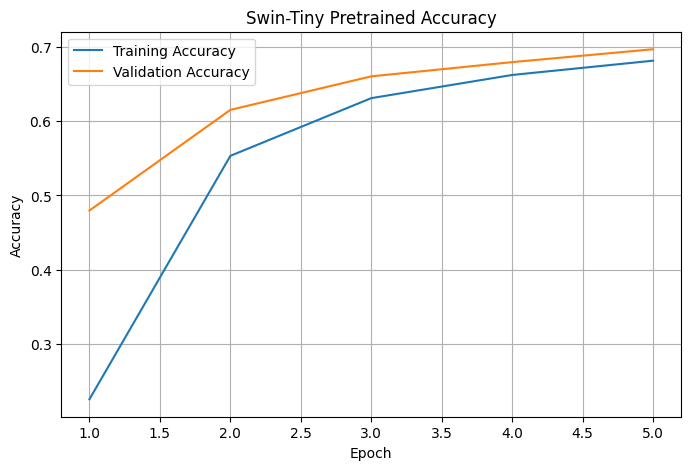

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,4.103343,3.548467,0.225022,0.4796,19.845497,2.138101,21.984333
1,2,3.130767,2.706258,0.553356,0.6154,20.048114,2.141597,22.190532
2,3,2.425668,2.128524,0.631200,0.6606,19.845154,2.158547,22.004985
3,4,1.956383,1.759957,0.662467,0.6798,19.807662,2.145854,21.955058
4,5,1.658520,1.528098,0.681733,0.6972,19.810065,2.161155,21.972012


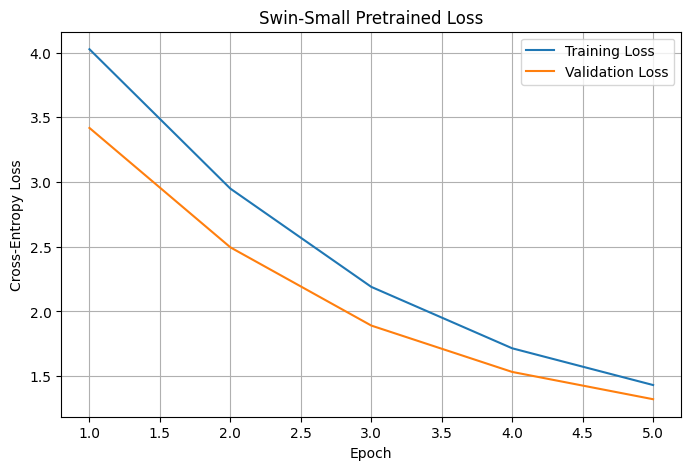

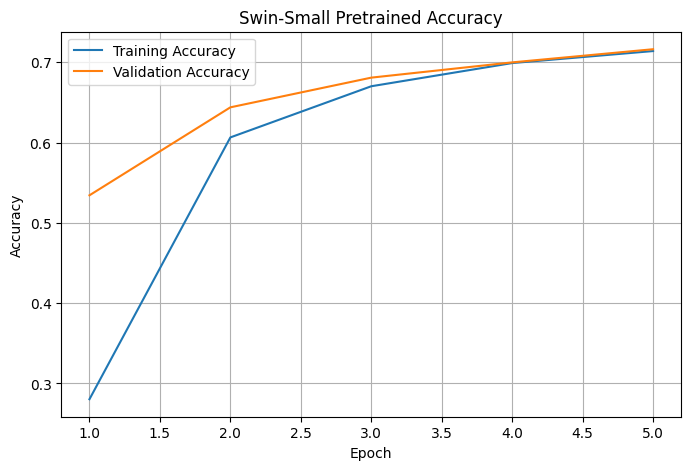

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,4.026146,3.417882,0.280356,0.5344,35.231998,3.770891,39.004457
1,2,2.949034,2.495364,0.606533,0.6440,35.431549,3.715611,39.148982
2,3,2.189845,1.890904,0.670267,0.6810,35.153888,3.749997,38.905462
3,4,1.715226,1.532582,0.699156,0.7000,35.179191,3.767042,38.948092
4,5,1.431332,1.321703,0.714111,0.7164,34.706451,3.765101,38.473310


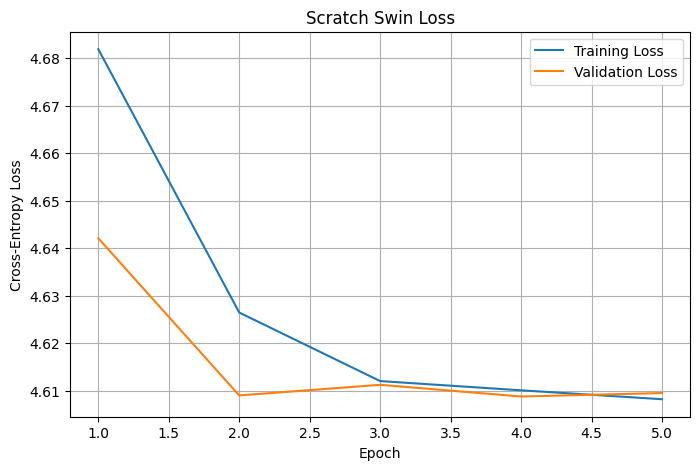

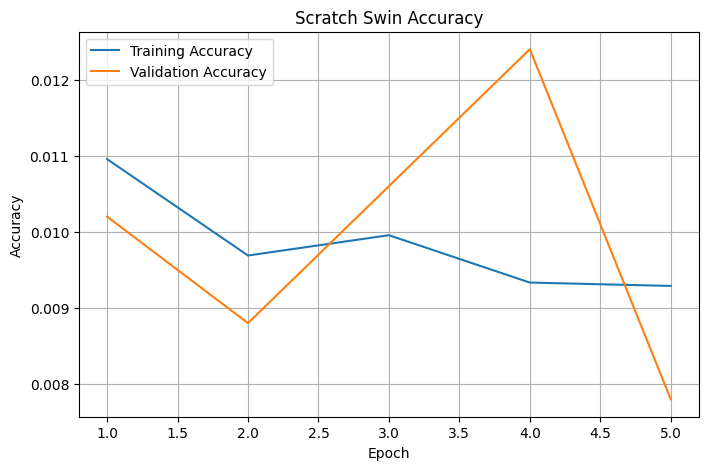

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Training Time,Validation Time,Complete Epoch Time
0,1,4.681871,4.642085,0.010956,0.0102,58.652523,2.180842,60.834764
1,2,4.626463,4.609024,0.009689,0.0088,58.465032,2.166194,60.633147
2,3,4.612045,4.611256,0.009956,0.0106,58.402337,2.173220,60.576911
3,4,4.610100,4.608800,0.009333,0.0124,58.401732,2.171471,60.574482
4,5,4.608227,4.609526,0.009289,0.0078,58.580184,2.172800,60.754477


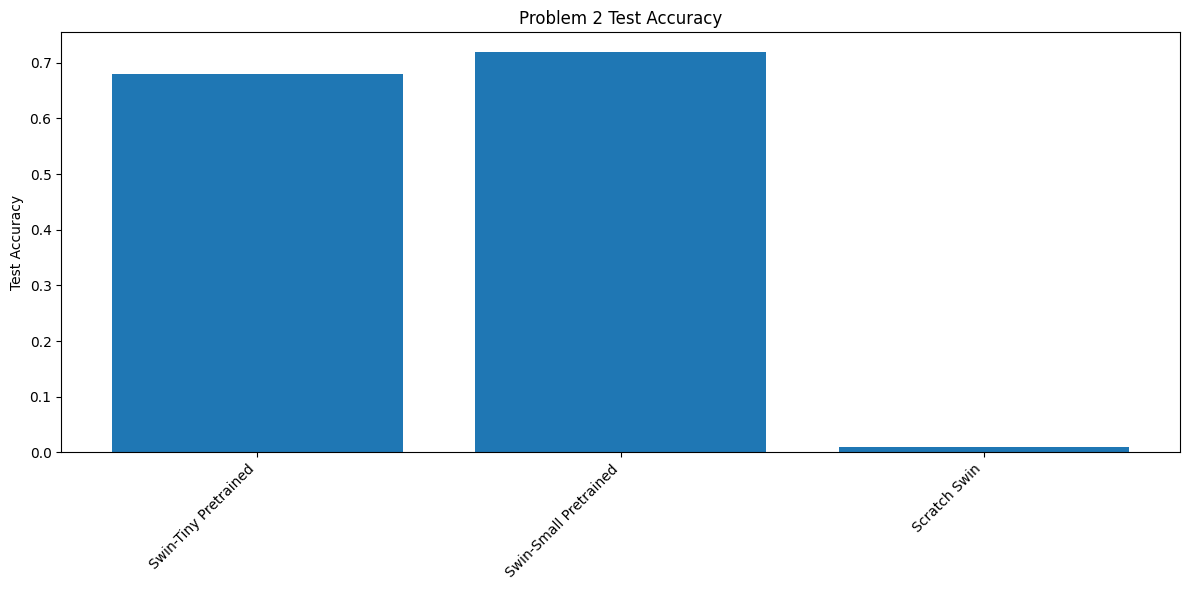

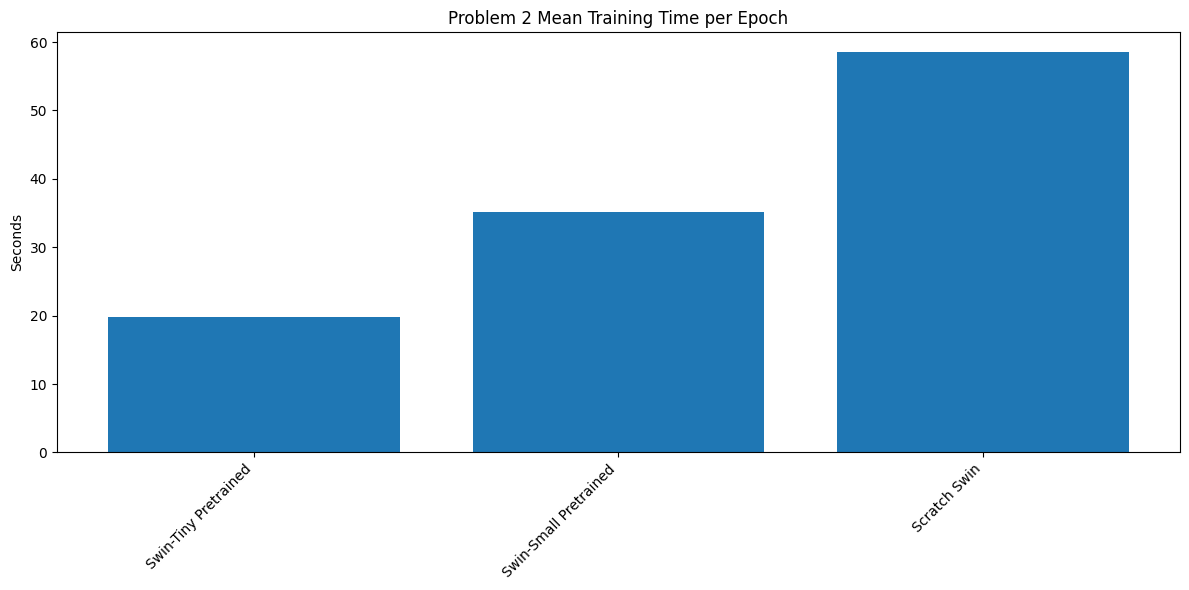

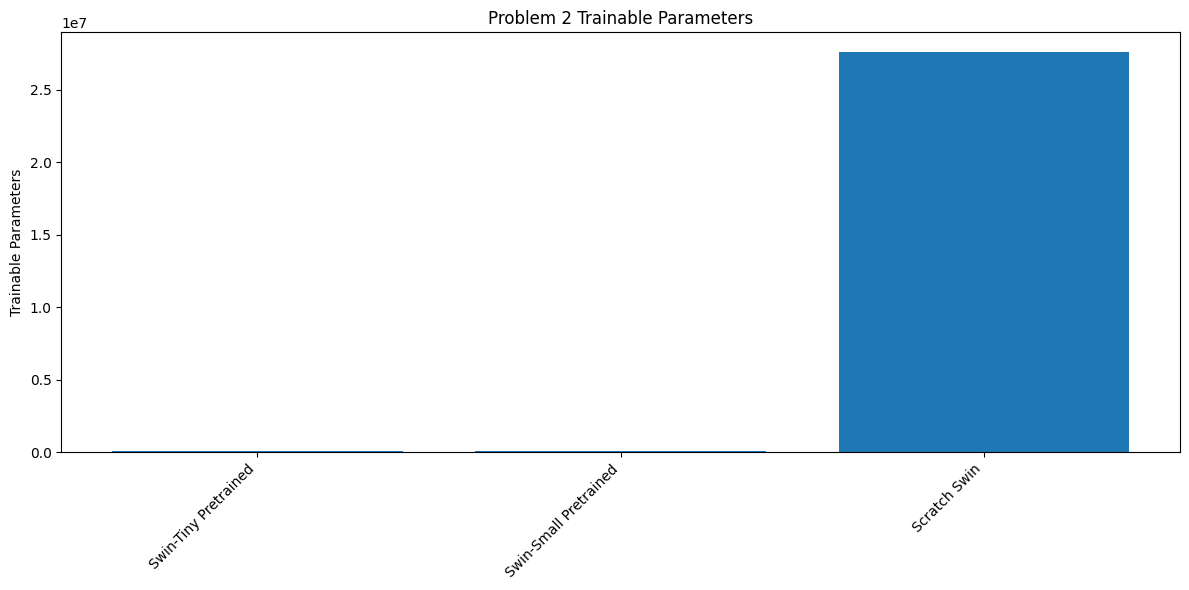

In [78]:
# 84. Problem 2 Results
PROBLEM2_RESULTS = (
    PROBLEM2_SWIN_RESULTS
)

PROBLEM2_TABLE = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "history"
    }
    for result in PROBLEM2_RESULTS
])

display(PROBLEM2_TABLE)

for result in PROBLEM2_RESULTS:
    display(display_history(result))

plot_result_metric(
    PROBLEM2_RESULTS,
    "test_accuracy",
    "Problem 2 Test Accuracy",
    "Test Accuracy"
)

plot_result_metric(
    PROBLEM2_RESULTS,
    "mean_training_time_per_epoch",
    "Problem 2 Mean Training Time per Epoch",
    "Seconds"
)

plot_result_metric(
    PROBLEM2_RESULTS,
    "trainable_parameters",
    "Problem 2 Trainable Parameters",
    "Trainable Parameters"
)


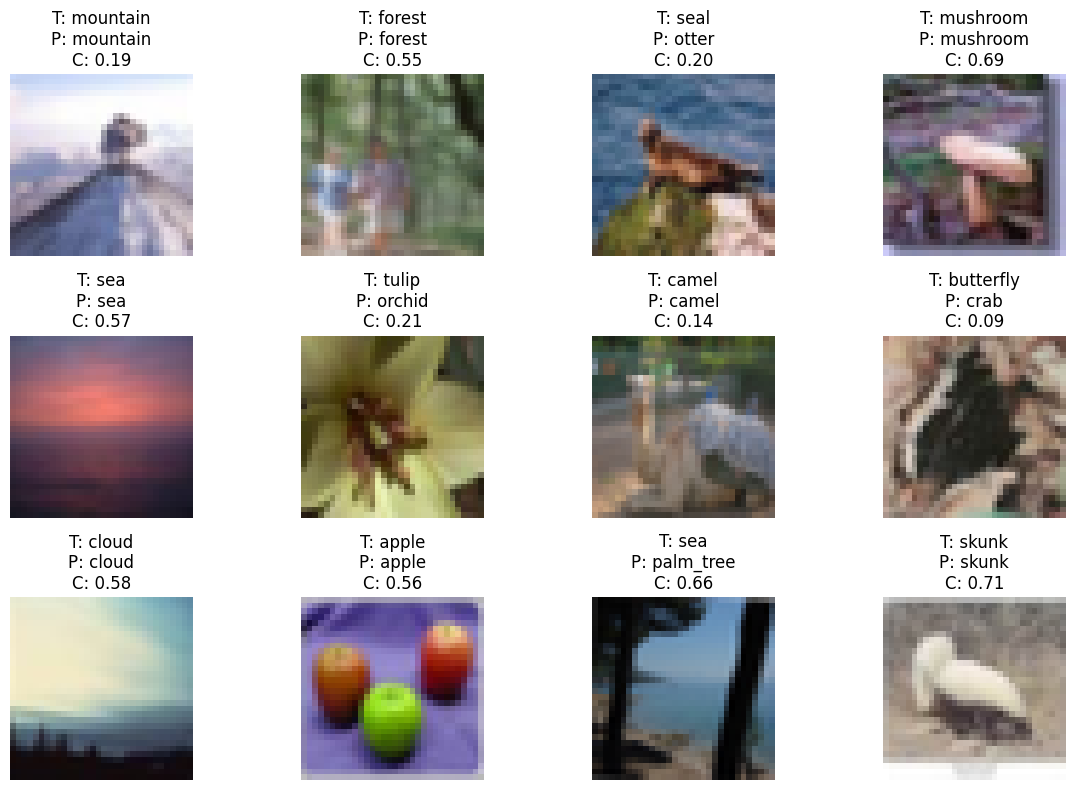

In [79]:
# 85. Problem 2 Qualitative Results
BEST_PROBLEM2_MODEL = max(
    PROBLEM2_RESULTS,
    key=lambda result: result[
        "best_validation_accuracy"
    ]
)

best_problem2_model = (
    PROBLEM2_SWIN_MODELS[
        BEST_PROBLEM2_MODEL[
            "model_name"
        ]
    ].to(DEVICE)
)

display_predictions_on_indices(
    best_problem2_model,
    RAW_TEST_DATASET,
    QUALITATIVE_INDICES,
    P2_EVAL_TRANSFORM
)


# 86. Final Comparison Heading

In [80]:
# 87. Combined Results Table
ALL_RESULTS = (
    PROBLEM1_RESULTS
    + PROBLEM2_RESULTS
)

DETAILED_RESULTS_TABLE = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "history"
    }
    for result in ALL_RESULTS
])

SUMMARY_COLUMNS = [
    "model_name",
    "training_mode",
    "total_parameters",
    "trainable_parameters",
    "model_size_mb",
    "estimated_flops",
    "best_validation_loss_epoch",
    "best_validation_loss",
    "validation_accuracy_at_best_loss",
    "best_validation_accuracy_epoch",
    "best_validation_accuracy",
    "validation_loss_at_best_accuracy",
    "test_accuracy",
    "top5_accuracy",
    "mean_training_time_per_epoch",
    "total_training_time",
    "clean_generalization_gap",
    "learning_status",
]

COMBINED_RESULTS_TABLE = (
    DETAILED_RESULTS_TABLE[
        SUMMARY_COLUMNS
    ]
)

COMBINED_RESULTS_TABLE


,model_name,training_mode,total_parameters,trainable_parameters,model_size_mb,estimated_flops,best_validation_loss_epoch,best_validation_loss,validation_accuracy_at_best_loss,best_validation_accuracy_epoch,best_validation_accuracy,validation_loss_at_best_accuracy,test_accuracy,top5_accuracy,mean_training_time_per_epoch,total_training_time,clean_generalization_gap,learning_status
0,ViT-P4-D256-L4-H4,Scratch,3214692,3214692,12.263077,213937152,8,2.797642,0.2868,10,0.2912,2.804013,0.2840,0.5973,3.981480,39.814803,0.017933,Overfitting after best validation-loss epoch
1,ViT-P8-D256-L4-H4,Scratch,3239268,3239268,12.356827,54881280,9,3.669287,0.1330,9,0.1330,3.669287,0.1200,0.3590,3.387287,33.872873,-0.003867,Stable or mixed convergence
2,ViT-P4-D256-L8-H4,Scratch,6373732,6373732,24.313858,427062272,10,3.048133,0.2448,10,0.2448,3.048133,0.2397,0.5315,6.899756,68.997559,0.010267,Still converging at final epoch
3,ViT-P4-D512-L4-H8,Scratch,12720740,12720740,48.525772,836818944,5,3.867316,0.1030,5,0.1030,3.867316,0.0994,0.3057,7.141013,71.410129,-0.004733,Stable or mixed convergence
4,ResNet-18,Scratch,11220132,11220132,42.801407,556705792,9,1.555851,0.5752,9,0.5752,1.555851,0.5722,0.8524,4.329855,43.298554,0.083089,Overfitting after best validation-loss epoch
5,Swin-Tiny Pretrained,Pretrained Frozen Backbone,27596254,76900,105.271355,4368361728,5,1.528098,0.6972,5,0.6972,1.528098,0.6806,0.9206,19.871298,99.356492,0.001622,Still converging at final epoch
6,Swin-Small Pretrained,Pretrained Frozen Backbone,48914158,76900,186.592705,8539191552,5,1.321703,0.7164,5,0.7164,1.321703,0.7187,0.9401,35.140615,175.703077,0.012133,Still converging at final epoch
7,Scratch Swin,Manual Scratch Implementation,27596254,27596254,105.271355,4508503296,4,4.608800,0.0124,4,0.0124,4.608800,0.0100,0.0500,58.500361,292.501807,-0.002667,Failed learning / severe underfitting


In [81]:
# 88. Best Validation-Loss Model
BEST_VALIDATION_LOSS_MODEL = min(
    ALL_RESULTS,
    key=lambda result: result[
        "best_validation_loss"
    ]
)

pd.DataFrame([{
    key: value
    for key, value
    in BEST_VALIDATION_LOSS_MODEL.items()
    if key != "history"
}])


,model_name,model_family,training_mode,patch_size,embedding_dimension,transformer_blocks,attention_heads,mlp_dimension,total_parameters,trainable_parameters,...,clean_generalization_gap,test_loss,test_accuracy,top5_accuracy,mean_training_time_per_epoch,mean_validation_time_per_epoch,mean_complete_epoch_time,total_training_time,total_experiment_time,learning_status
0,Swin-Small Pretrained,Swin Transformer,Pretrained Frozen Backbone,4,96,24,"[3, 6, 12, 24]",3072,48914158,76900,...,0.012133,1.339383,0.7187,0.9401,35.140615,3.753728,38.896061,175.703077,194.480303,Still converging at final epoch


In [82]:
# 89. Best Validation-Metric Model
BEST_VALIDATION_ACCURACY_MODEL = max(
    ALL_RESULTS,
    key=lambda result: result[
        "best_validation_accuracy"
    ]
)

pd.DataFrame([{
    key: value
    for key, value
    in BEST_VALIDATION_ACCURACY_MODEL.items()
    if key != "history"
}])


,model_name,model_family,training_mode,patch_size,embedding_dimension,transformer_blocks,attention_heads,mlp_dimension,total_parameters,trainable_parameters,...,clean_generalization_gap,test_loss,test_accuracy,top5_accuracy,mean_training_time_per_epoch,mean_validation_time_per_epoch,mean_complete_epoch_time,total_training_time,total_experiment_time,learning_status
0,Swin-Small Pretrained,Swin Transformer,Pretrained Frozen Backbone,4,96,24,"[3, 6, 12, 24]",3072,48914158,76900,...,0.012133,1.339383,0.7187,0.9401,35.140615,3.753728,38.896061,175.703077,194.480303,Still converging at final epoch


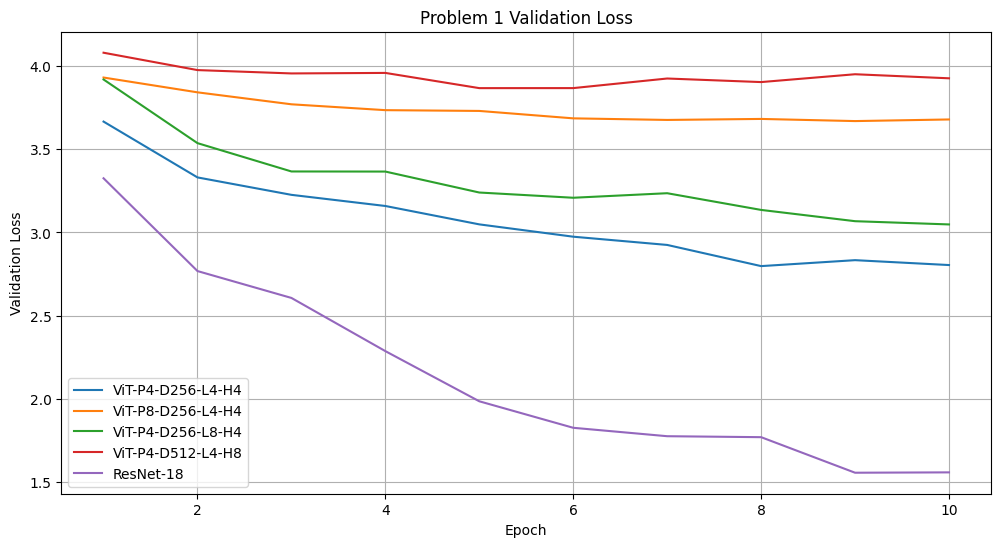

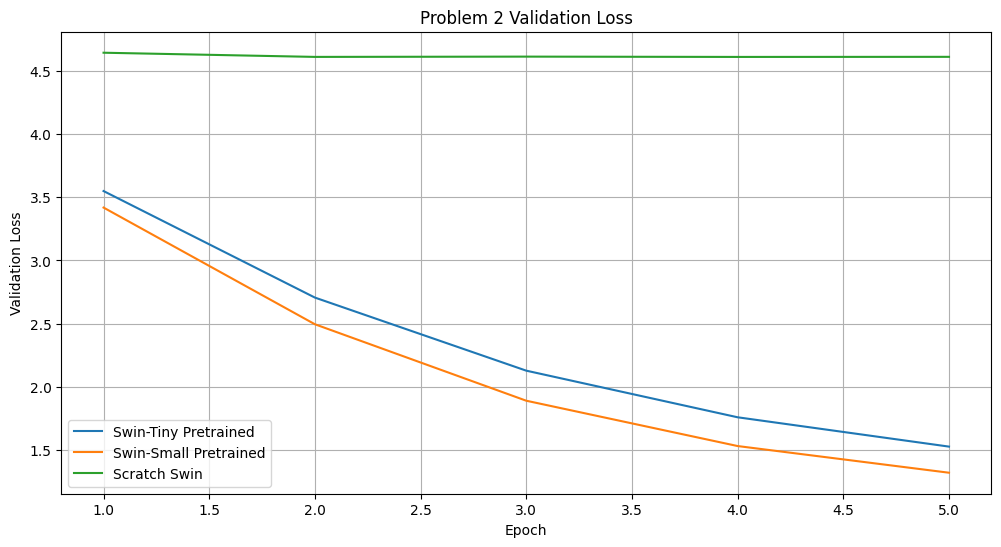

In [83]:
# 90. Validation-Loss Comparison Plot
def plot_validation_loss_comparison(
    results,
    title
):
    plt.figure(figsize=(12, 6))

    for result in results:
        history = result["history"]

        plt.plot(
            range(
                1,
                len(
                    history[
                        "validation_loss"
                    ]
                ) + 1
            ),
            history["validation_loss"],
            label=result["model_name"]
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_validation_loss_comparison(
    PROBLEM1_RESULTS,
    "Problem 1 Validation Loss"
)

plot_validation_loss_comparison(
    PROBLEM2_RESULTS,
    "Problem 2 Validation Loss"
)


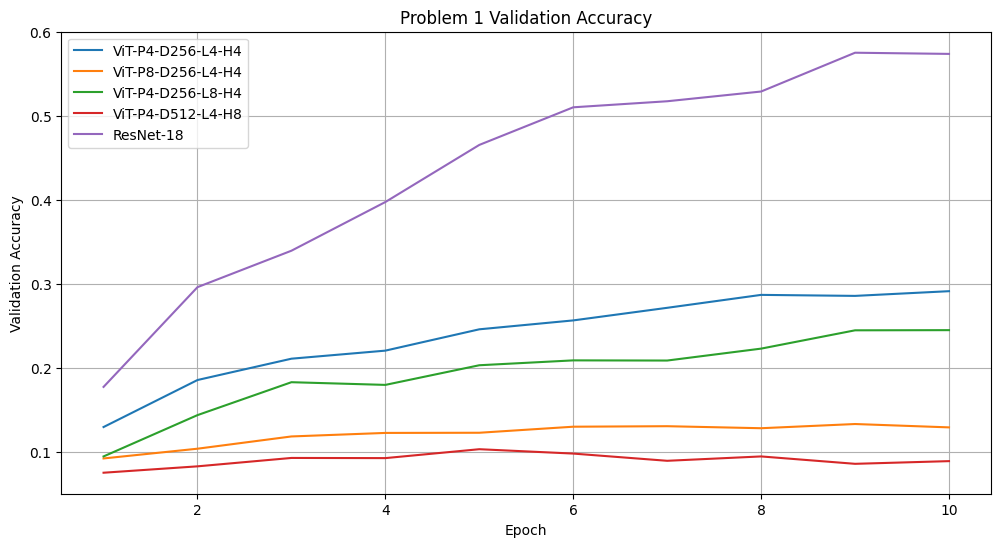

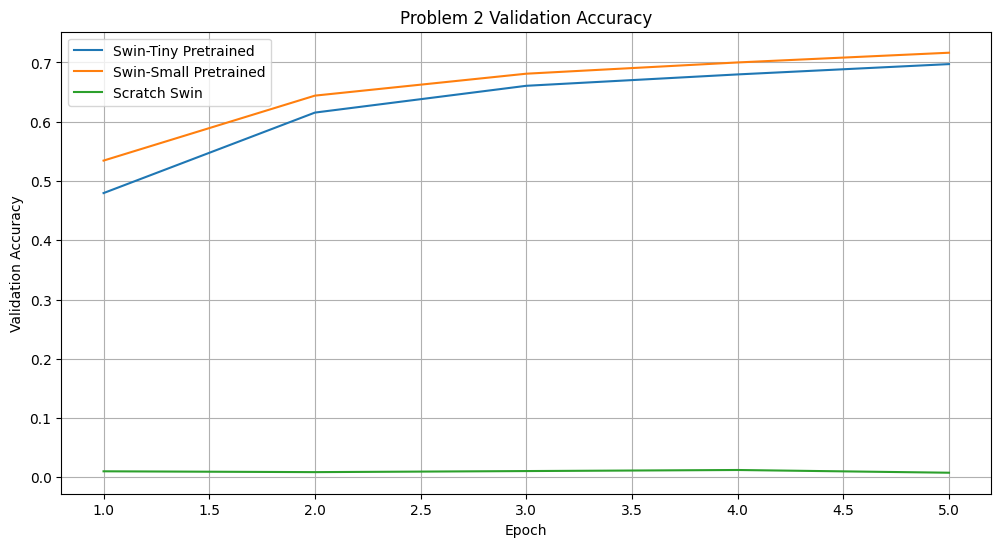

In [84]:
# 91. Validation-Metric Comparison Plot
def plot_validation_accuracy_comparison(
    results,
    title
):
    plt.figure(figsize=(12, 6))

    for result in results:
        history = result["history"]

        plt.plot(
            range(
                1,
                len(
                    history[
                        "validation_accuracy"
                    ]
                ) + 1
            ),
            history["validation_accuracy"],
            label=result["model_name"]
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_validation_accuracy_comparison(
    PROBLEM1_RESULTS,
    "Problem 1 Validation Accuracy"
)

plot_validation_accuracy_comparison(
    PROBLEM2_RESULTS,
    "Problem 2 Validation Accuracy"
)


In [85]:
# 92. Training-Validation Gap Table
TRAINING_VALIDATION_GAP_TABLE = (
    pd.DataFrame([
        {
            "Model": result[
                "model_name"
            ],
            "Clean Training Accuracy": (
                result[
                    "clean_training_accuracy"
                ]
            ),
            "Selected Validation Accuracy": (
                result[
                    "selected_validation_accuracy"
                ]
            ),
            "Clean Generalization Gap": (
                result[
                    "clean_generalization_gap"
                ]
            ),
            "Best Validation Loss": (
                result[
                    "best_validation_loss"
                ]
            ),
            "Final Validation Loss": (
                result["history"][
                    "validation_loss"
                ][-1]
            ),
            "Learning Status": (
                result[
                    "learning_status"
                ]
            ),
        }
        for result in ALL_RESULTS
    ])
)

TRAINING_VALIDATION_GAP_TABLE


,Model,Clean Training Accuracy,Selected Validation Accuracy,Clean Generalization Gap,Best Validation Loss,Final Validation Loss,Learning Status
0,ViT-P4-D256-L4-H4,0.304733,0.2868,0.017933,2.797642,2.804013,Overfitting after best validation-loss epoch
1,ViT-P8-D256-L4-H4,0.129133,0.1330,-0.003867,3.669287,3.679016,Stable or mixed convergence
2,ViT-P4-D256-L8-H4,0.255067,0.2448,0.010267,3.048133,3.048133,Still converging at final epoch
3,ViT-P4-D512-L4-H8,0.098267,0.1030,-0.004733,3.867316,3.926430,Stable or mixed convergence
4,ResNet-18,0.658289,0.5752,0.083089,1.555851,1.557977,Overfitting after best validation-loss epoch
5,Swin-Tiny Pretrained,0.698822,0.6972,0.001622,1.528098,1.528098,Still converging at final epoch
6,Swin-Small Pretrained,0.728533,0.7164,0.012133,1.321703,1.321703,Still converging at final epoch
7,Scratch Swin,0.009733,0.0124,-0.002667,4.608800,4.609526,Failed learning / severe underfitting


In [86]:
# 93. Overfitting Analysis
OVERFITTING_ANALYSIS = pd.DataFrame([
    {
        "Model": result["model_name"],
        "Best Validation-Loss Epoch": (
            result[
                "best_validation_loss_epoch"
            ]
        ),
        "Final Epoch": len(
            result["history"][
                "validation_loss"
            ]
        ),
        "Clean Generalization Gap": (
            result[
                "clean_generalization_gap"
            ]
        ),
        "Validation-Loss Increase After Best Epoch": (
            result["history"][
                "validation_loss"
            ][-1]
            - result[
                "best_validation_loss"
            ]
        ),
        "Learning Status": (
            result["learning_status"]
        ),
    }
    for result in ALL_RESULTS
])

OVERFITTING_ANALYSIS


,Model,Best Validation-Loss Epoch,Final Epoch,Clean Generalization Gap,Validation-Loss Increase After Best Epoch,Learning Status
0,ViT-P4-D256-L4-H4,8,10,0.017933,0.006371,Overfitting after best validation-loss epoch
1,ViT-P8-D256-L4-H4,9,10,-0.003867,0.009729,Stable or mixed convergence
2,ViT-P4-D256-L8-H4,10,10,0.010267,0.000000,Still converging at final epoch
3,ViT-P4-D512-L4-H8,5,10,-0.004733,0.059114,Stable or mixed convergence
4,ResNet-18,9,10,0.083089,0.002126,Overfitting after best validation-loss epoch
5,Swin-Tiny Pretrained,5,5,0.001622,0.000000,Still converging at final epoch
6,Swin-Small Pretrained,5,5,0.012133,0.000000,Still converging at final epoch
7,Scratch Swin,4,5,-0.002667,0.000726,Failed learning / severe underfitting


In [87]:
# 94. Convergence Comparison
CHECKPOINT_COMPARISON_TABLE = pd.DataFrame([
    {
        "Model": result["model_name"],
        "Best Loss Epoch": result[
            "best_validation_loss_epoch"
        ],
        "Best Validation Loss": result[
            "best_validation_loss"
        ],
        "Accuracy at Best Loss": result[
            "validation_accuracy_at_best_loss"
        ],
        "Best Accuracy Epoch": result[
            "best_validation_accuracy_epoch"
        ],
        "Best Validation Accuracy": result[
            "best_validation_accuracy"
        ],
        "Loss at Best Accuracy": result[
            "validation_loss_at_best_accuracy"
        ],
    }
    for result in ALL_RESULTS
])

display(CHECKPOINT_COMPARISON_TABLE)

CONVERGENCE_TABLE = pd.DataFrame([
    {
        "Model": result["model_name"],
        "Final Epoch": len(
            result["history"][
                "validation_loss"
            ]
        ),
        "Mean Training Time per Epoch": (
            result[
                "mean_training_time_per_epoch"
            ]
        ),
        "Mean Validation Time per Epoch": (
            result[
                "mean_validation_time_per_epoch"
            ]
        ),
        "Mean Complete Epoch Time": (
            result[
                "mean_complete_epoch_time"
            ]
        ),
        "Learning Status": (
            result["learning_status"]
        ),
    }
    for result in ALL_RESULTS
])

CONVERGENCE_TABLE


,Model,Best Loss Epoch,Best Validation Loss,Accuracy at Best Loss,Best Accuracy Epoch,Best Validation Accuracy,Loss at Best Accuracy
0,ViT-P4-D256-L4-H4,8,2.797642,0.2868,10,0.2912,2.804013
1,ViT-P8-D256-L4-H4,9,3.669287,0.1330,9,0.1330,3.669287
2,ViT-P4-D256-L8-H4,10,3.048133,0.2448,10,0.2448,3.048133
3,ViT-P4-D512-L4-H8,5,3.867316,0.1030,5,0.1030,3.867316
4,ResNet-18,9,1.555851,0.5752,9,0.5752,1.555851
5,Swin-Tiny Pretrained,5,1.528098,0.6972,5,0.6972,1.528098
6,Swin-Small Pretrained,5,1.321703,0.7164,5,0.7164,1.321703
7,Scratch Swin,4,4.608800,0.0124,4,0.0124,4.608800


,Model,Final Epoch,Mean Training Time per Epoch,Mean Validation Time per Epoch,Mean Complete Epoch Time,Learning Status
0,ViT-P4-D256-L4-H4,10,3.981480,0.209348,4.191443,Overfitting after best validation-loss epoch
1,ViT-P8-D256-L4-H4,10,3.387287,0.200031,3.588110,Stable or mixed convergence
2,ViT-P4-D256-L8-H4,10,6.899756,0.351927,7.252598,Still converging at final epoch
3,ViT-P4-D512-L4-H8,10,7.141013,0.347420,7.489148,Stable or mixed convergence
4,ResNet-18,10,4.329855,0.243857,4.574331,Overfitting after best validation-loss epoch
5,Swin-Tiny Pretrained,5,19.871298,2.149051,22.021384,Still converging at final epoch
6,Swin-Small Pretrained,5,35.140615,3.753728,38.896061,Still converging at final epoch
7,Scratch Swin,5,58.500361,2.172905,60.674756,Failed learning / severe underfitting


Best Scratch ViT


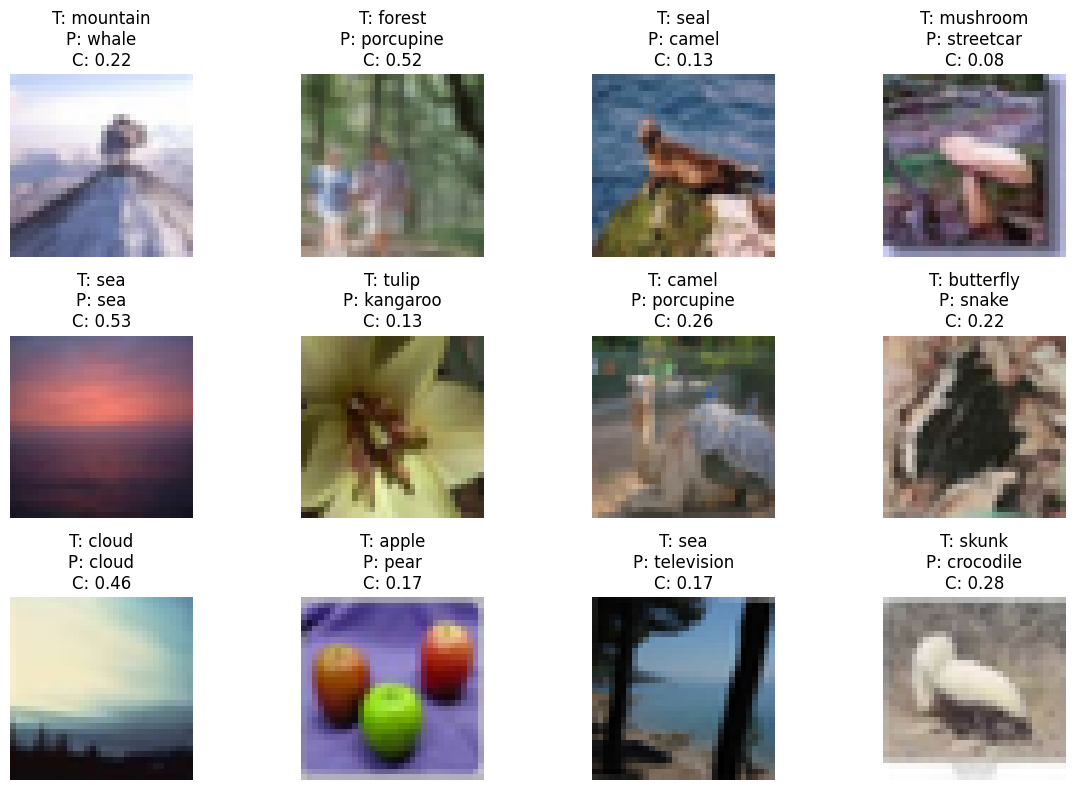

ResNet-18


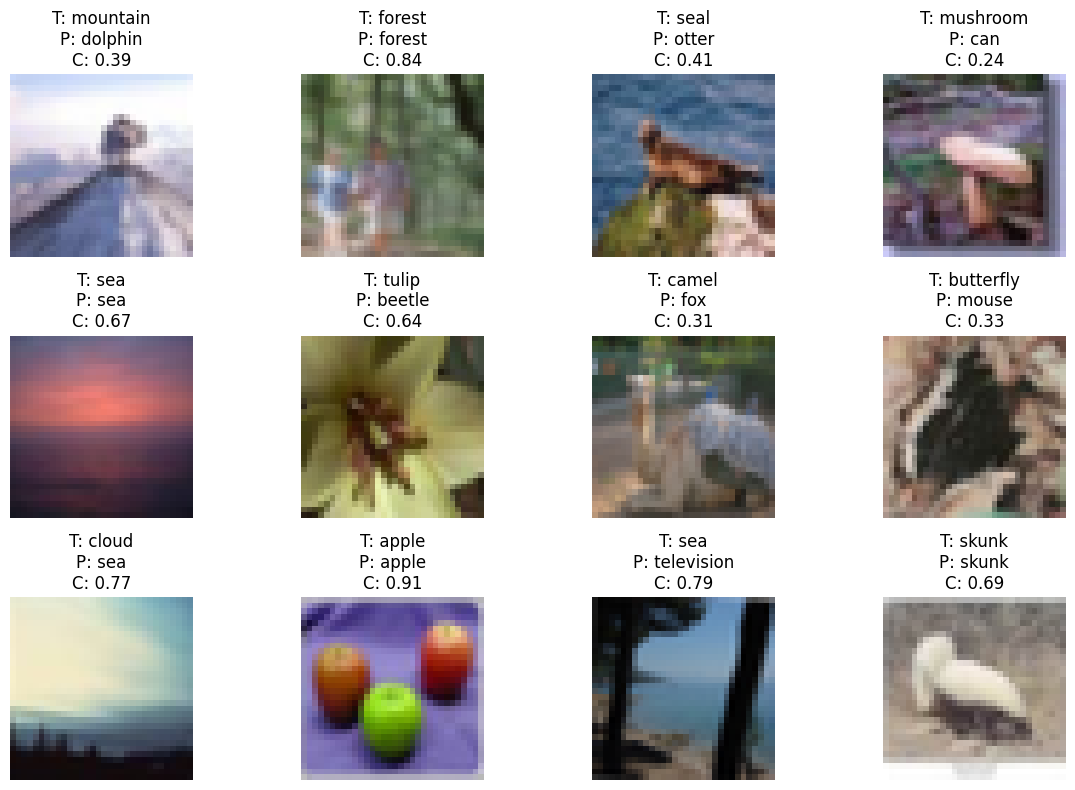

Swin-Tiny Pretrained


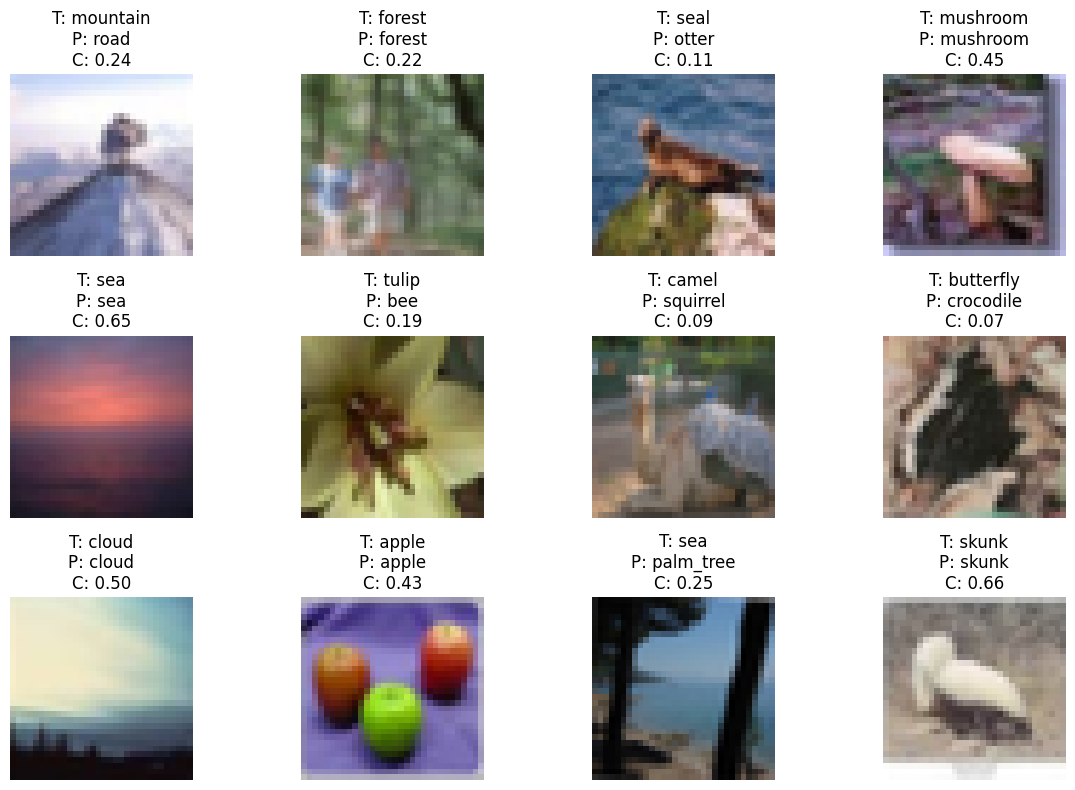

Swin-Small Pretrained


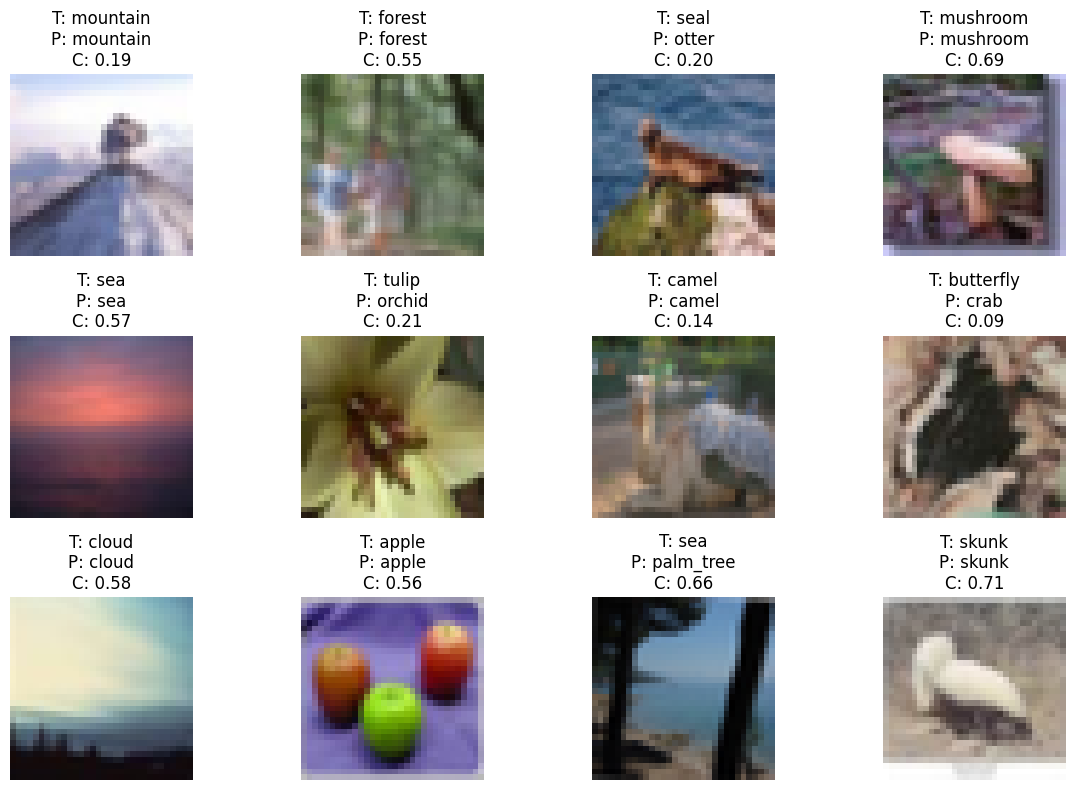

Scratch Swin


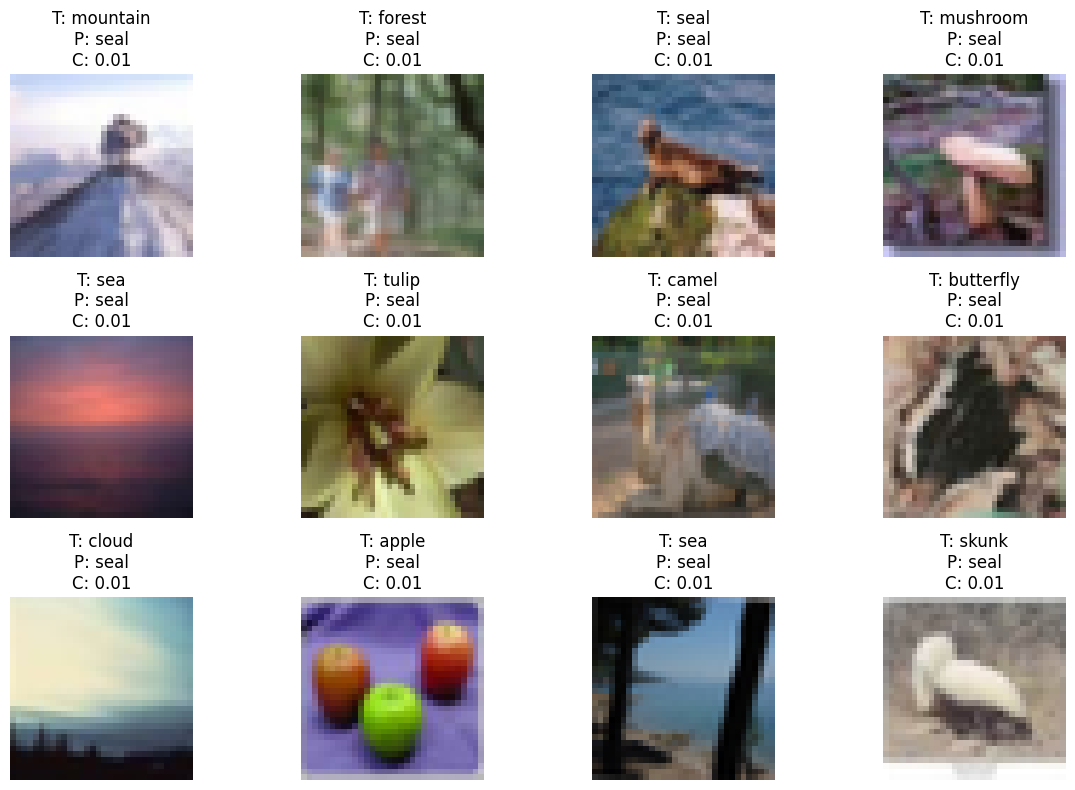

In [88]:
# 95. Qualitative Output Comparison
BEST_SCRATCH_VIT_RESULT = max(
    PROBLEM1_VIT_RESULTS,
    key=lambda result: result[
        "best_validation_accuracy"
    ]
)

QUALITATIVE_MODELS = {
    "Best Scratch ViT": (
        PROBLEM1_VIT_MODELS[
            BEST_SCRATCH_VIT_RESULT[
                "model_name"
            ]
        ].to(DEVICE),
        P1_EVAL_TRANSFORM
    ),
    "ResNet-18": (
        RESNET_MODEL.to(DEVICE),
        P1_EVAL_TRANSFORM
    ),
    "Swin-Tiny Pretrained": (
        PROBLEM2_SWIN_MODELS[
            "Swin-Tiny Pretrained"
        ].to(DEVICE),
        P2_EVAL_TRANSFORM
    ),
    "Swin-Small Pretrained": (
        PROBLEM2_SWIN_MODELS[
            "Swin-Small Pretrained"
        ].to(DEVICE),
        P2_EVAL_TRANSFORM
    ),
    "Scratch Swin": (
        PROBLEM2_SWIN_MODELS[
            "Scratch Swin"
        ].to(DEVICE),
        P2_EVAL_TRANSFORM
    ),
}

for label, (
    model,
    transform
) in QUALITATIVE_MODELS.items():
    print(label)

    display_predictions_on_indices(
        model,
        RAW_TEST_DATASET,
        QUALITATIVE_INDICES,
        transform
    )
